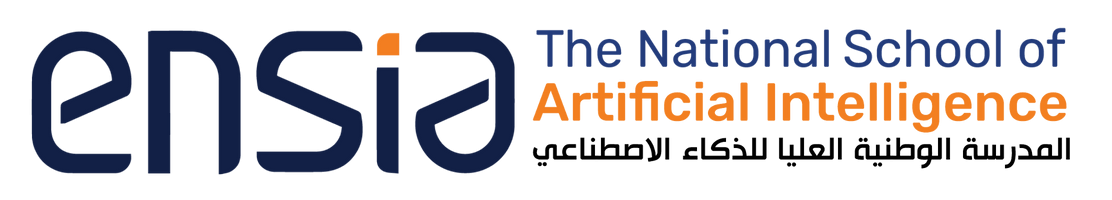

# University Course-to-Room Allocator (UCRA)
### AI-Powered Optimization for Academic Scheduling — ENSIA, Spring 2026

This notebook implements an intelligent timetabling system for the **University Course-to-Room Allocation** problem. Rather than relying on manual scheduling, the system uses a two-phase AI pipeline to assign 469 course events to rooms and timeslots while satisfying all physical constraints and maximizing schedule quality.

---

## Overview

The system operates in two sequential phases:

1. **Phase 1 — Feasibility (CSP):** Produces a hard-constraint-satisfying initial schedule using either a systematic backtracking search (Global Search CSP) or a repair-based approach (Local Search CSP with Min-Conflicts).

2. **Phase 2 — Optimization (Local Search):** Improves the initial schedule by minimizing soft constraint penalties — such as idle gaps, seat waste, and room changes — using metaheuristic algorithms.

---

## Optimization Algorithms

Four local search strategies are implemented and compared:

- **Hill Climbing (HC):** Greedy descent with three variants — Steepest, First Choice, and Stochastic.
- **Random Restart Hill Climbing (RRHC):** Runs HC from multiple independent starting points and retains the global best.
- **Simulated Annealing (SA):** Uses a temperature-controlled acceptance probability to escape local optima.
- **Tabu Search (TS):** Maintains a memory of recent moves to prevent cycling and force exploration of unvisited regions.

---

## Constraints at a Glance

| Hard Constraints | Soft Constraints |
|---|---|
| No room, group, or teacher double-booking | Minimize idle gaps in daily schedules |
| Room capacity ≥ event headcount | Minimize wasted seating capacity |
| Room type must match event requirements | Keep lecture sections in adjacent slots |
| No student group exceeds 3 consecutive slots | Prefer morning slots for lectures |
| | Minimize teacher working days |
| | Penalize Thursday afternoon and last-slot sessions |
| | Minimize room changes between consecutive sessions |

---

## Output

The final section generates a visual dashboard including room occupancy heatmaps, room utilization heatmaps, and professor schedule heatmaps — making the quality improvement from optimization immediately visible.

### Setup

Run the following cell to install the required dependencies.

In [12]:
pip install streamlit numpy matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [13]:
from math import exp
import random
from collections import deque
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from IPython.display import Image, display

## The Constraint Engine

The `Constraints` class is the evaluation core of the system. It determines whether a given schedule is feasible and how good it is.

---

### Preprocessing: Lookup Tables

Before evaluating any constraint, `_build_lookup_tables` transforms the raw state dictionary into four resource-centric mappings:

- `slot_to_rooms` — which rooms are occupied at each timeslot
- `slot_to_groups` — which student groups are busy at each timeslot
- `slot_to_teachers` — which teachers are teaching at each timeslot
- `teacher_events` — which events each teacher is assigned to

This preprocessing step runs once per evaluation call, after which individual constraint checks become O(1) lookups rather than O(n) scans.

---

### Hard Constraints

Hard constraints represent non-negotiable physical requirements. A single violation makes the schedule invalid.

| Constraint | What it checks |
|---|---|
| `NO_ROOM_DOUBLE_BOOKING` | No room assigned to more than one event per slot |
| `NO_GROUP_DOUBLE_BOOKING` | No student group in two events simultaneously |
| `NO_TEACHER_DOUBLE_BOOKING` | No teacher teaching two events at the same time |
| `ROOM_CAPACITY_GEQ_HEADCOUNT` | Room capacity ≥ event headcount |
| `MATCH_ROOM_TYPE` | Room type matches the event's required type (amphi, lab, tutorial) |
| `MAX_CONSECUTIVE_STUDENT_SLOTS_3` | No group scheduled for more than 3 consecutive periods per day |

---

### Soft Constraints

Soft constraints define schedule quality. Each violation contributes a weighted penalty to the total cost. Constraints are grouped into 3 categories:

| Constraint | Category | Weight | What it penalizes |
|---|---|---|---|
| `MINIMIZE_GAPS` | Group/Prof | 9 | Ide slots between sessions in a daily schedule |
| `SIMILAR_ACTIVITIES` | External | 5.5 | Lecture sections for the same course not held in adjacent slots |
| `MINIMIZE_TEACHER_DAYS` | Prof | 7 | Teachers spread across more working days than necessary |
| `MINIMIZE_ROOM_CHANGES` | Group/Prof | 5 | Costly room changes between consecutive sessions (floor/zone distance) |
| `MORNING_LECTURES` | General | 4.5 | Lectures scheduled late in the day |
| `AVOID_THURSDAY_AFTERNOON` | Group/Prof | 3 | Sessions in Thursday afternoon slots (13:30–18:20) |
| `AVOID_LAST_SLOT` | Group/Prof | 3 | Sessions in the 16:50–18:20 period |
| `MINIMIZE_WASTED_SEATS` | External | 1 | Percentage of unused capacity in the assigned room |
| `SEPERATE_LECTURE_PRACTICE` | Exrternal | 1.5 | Lectures and Practice sessions NOT to be in the same day |

---

### Evaluation Formula

The total soft penalty for a schedule $S$ is:

$$f(S) = \alpha \sum_{g \in G} \text{Cost}(g) + \beta \sum_{p \in P} \text{Cost}(p) + \sum_{c \in C} \text{Penalty}(c)$$

Where g is the set of groups, p is the set of Professors and C represents the set of external constraints.
Each cost is computed as the weighted average : $w_c$ is the weight of constraint $c$ and $v_c(S)$ is the number of violations it detects in state $S$. The optimization algorithms minimize $f(S)$ while preserving all hard constraints.

In [14]:
class Constraints:
    # includes the constraints functions, seperated for clean structure
    def __init__(self, problem):
        self.problem = problem
    
    # build lookup tables once before looping, then check per constraint.
    def _build_lookup_tables(self, state):
        """
        Preprocesses the current schedule state into resource-centric lookup tables 
        for highly efficient constraint evaluation.

        Args:
            state (dict): The current assignment mapping event_id -> (roomid, slot).

        Returns:
            tuple: Four dictionaries mapping slots to rooms, groups, and teachers, 
                   plus a mapping of teachers to their assigned events.
        """
        from collections import defaultdict
        slot_to_rooms    = defaultdict(list)  
        slot_to_groups   = defaultdict(list)  
        slot_to_teachers = defaultdict(list)
        teacher_events   = defaultdict(list) 

        for event_id, (roomid, slot) in state.items():
            event = self.problem.events_by_id[event_id]
            teacher_id = event["teacher_id"]

            slot_to_rooms[slot].append(roomid)
            slot_to_teachers[slot].append(teacher_id)
            teacher_events[teacher_id].append(event_id)

            if event["type_id"] == 1: 
                for gid in self.problem.section_to_group[event["target_id"]]:
                    slot_to_groups[slot].append(gid)
            else:                      
                slot_to_groups[slot].append(event["target_id"])

        return slot_to_rooms, slot_to_groups, slot_to_teachers, teacher_events
    
    # Hard constraints methods
    # DOUBLE BOOKING

    def NO_ROOM_DOUBLE_BOOKING(self, slot_to_rooms, count=True):
        """
        Checks if any room is assigned to more than one event during the same timeslot.

        Args:
            slot_to_rooms (dict): Mapping of timeslots to lists of assigned room IDs.
            count (bool): If True, returns the total violation count. If False, returns False on the first violation.

        Returns:
            int | bool: The number of violations, or a boolean indicating validity.
        """
        violations = 0
        for slot, rooms in slot_to_rooms.items():
            v = len(rooms) - len(set(rooms))
            if not count and v > 0: return False
            violations += v
        return violations if count else True

    def NO_GROUP_DOUBLE_BOOKING(self, slot_to_groups, count=True):
        """
        Checks if any student group is scheduled for multiple events during the same timeslot.

        Args:
            slot_to_groups (dict): Mapping of timeslots to lists of assigned group IDs.
            count (bool): If True, returns the total violation count. If False, returns False on the first violation.

        Returns:
            int | bool: The number of violations, or a boolean indicating validity.
        """
        violations = 0
        for slot, groups in slot_to_groups.items():
            v = len(groups) - len(set(groups))
            if not count and v > 0: return False
            violations += v
        return violations if count else True

    def NO_TEACHER_DOUBLE_BOOKING(self, slot_to_teachers, count=True):
        """
        Checks if any teacher is scheduled to teach multiple events during the same timeslot.

        Args:
            slot_to_teachers (dict): Mapping of timeslots to lists of assigned teacher IDs.
            count (bool): If True, returns the total violation count. If False, returns False on the first violation.

        Returns:
            int | bool: The number of violations, or a boolean indicating validity.
        """
        violations = 0
        for slot, teachers in slot_to_teachers.items():
            v = len(teachers) - len(set(teachers))
            if not count and v > 0: return False
            violations += v
        return violations if count else True

    # ROOM SUITABILITY

    def ROOM_CAPACITY_GEQ_HEADCOUNT(self, state, count=True):
        """
        Ensures the assigned room's capacity is greater than or equal to the event's student headcount.

        Args:
            state (dict): The current schedule assignment.
            count (bool): If True, returns the violation count. If False, returns False on the first violation.

        Returns:
            int | bool: The number of violations, or a boolean indicating validity.
        """
        violations = 0
        for event_id, (roomid, slot) in state.items():
            event = self.problem.events_by_id[event_id]
            room  = self.problem.rooms_by_id[roomid]
            if room["capacity"] < event["headcount"]:
                if not count: return False
                violations += 1
        return violations if count else True

    def MATCH_ROOM_TYPE(self, state, count=True):
        """
        Ensures the assigned room type matches the required room type for the event (e.g., lecture hall vs lab).

        Args:
            state (dict): The current schedule assignment.
            count (bool): If True, returns the violation count. If False, returns False on the first violation.

        Returns:
            int | bool: The number of violations, or a boolean indicating validity.
        """
        violations = 0
        for event_id, (roomid, slot) in state.items():
            event = self.problem.events_by_id[event_id]
            room  = self.problem.rooms_by_id[roomid]
            if room["room_type_id"] != event["required_room_type_id"]:
                if not count: return False
                violations += 1
        return violations if count else True

    # SCHEDULING STRUCTURE

    def MAX_CONSECUTIVE_STUDENT_SLOTS_3(self, state, count=True):
        """
        Ensures no student group is scheduled for more than 3 consecutive timeslots without a break.

        Args:
            state (dict): The current schedule assignment.
            count (bool): If True, returns the violation count. If False, returns False on the first violation.

        Returns:
            int | bool: The number of violations, or a boolean indicating validity.
        """
        from collections import defaultdict
        group_day_slots = defaultdict(lambda: defaultdict(set))
        for event_id, (roomid, slot) in state.items():
            event = self.problem.events_by_id[event_id]
            day, time = slot // 6, slot % 6
            groups = (self.problem.section_to_group[event["target_id"]]
                    if event["type_id"] == 1 else [event["target_id"]])
            for gid in groups:
                group_day_slots[gid][day].add(time)

        violations = 0
        for gid, days in group_day_slots.items():
            for day, times in days.items():
                sorted_times = sorted(times)
                run = max_run = 1
                for k in range(1, len(sorted_times)):
                    run = run + 1 if sorted_times[k] == sorted_times[k-1] + 1 else 1
                    max_run = max(max_run, run)
                if max_run > 3:
                    if not count: return False
                    violations += 1
        return violations if count else True

    # soft constraints methods

    # external constraints, need time table construction
    def SIMILAR_ACTIVITIES(self, state, weight):
        """
        for all lectures, it is preferable to have both sections study respectively
        Optimal for proffessors
        """
        from collections import defaultdict

        course_slots = defaultdict(list)
        # O(n)
        for event_id, (roomid, slot) in state.items():
            event_data = self.problem.events_by_id[event_id]
            if event_data["type_id"] != 1: continue
            course_slots[event_data["course_name"]].append(slot) # group all sections concerned by the lecture

        non_similar = 0
        for c, s in course_slots.items():
            if len(s) < 2: continue # only one section
            # check for evey pair of sections (useful if ensia will have many per year)
            # O(k^2) where k is section count which is 2-3 so not costly
            for i in range(len(s)):
                for j in range(i+1, len(s)):
                    diff = abs(s[i] - s[j])
                    same_day = (s[i] // 6) == (s[j] // 6)
                    if not (diff == 1 and same_day):
                        non_similar += 1
        return non_similar * weight

    def MINIMIZE_WASTED_SEATS(self, state, weight):
        """
        Penalize when an event is assigned in a -very much bigger- room
        """
        # O(n) per call
        wasted = 0
        for event_id, (roomid, slot) in state.items():
            event_data = self.problem.events_by_id[event_id]
            room_data = self.problem.rooms_by_id[roomid]
            wasted += (room_data["capacity"] - event_data["headcount"]) / room_data["capacity"] # take the percentage wasted 
        return wasted * weight
    
    def SEPARATE_LECTURE_PRACTICE(self, state, weight):
        """
        Prevents scheduling a lecture and a practice session for the same course and group on the same day.
        """
        from collections import defaultdict
        key_to_types = defaultdict(list)
        for event_id, (roomid, slot) in state.items():
            event = self.problem.events_by_id[event_id]
            day   = slot // 6
            groups = (self.problem.section_to_group[event["target_id"]]
                    if event["type_id"] == 1 else [event["target_id"]])
            for gid in groups:
                key_to_types[(gid, event["course_name"], day)].append(event["type_id"])

        violations = 0
        for (gid, course, day), types in key_to_types.items():
            if any(t == 1 for t in types) and any(t != 1 for t in types): # in the same day, there is a lecture AND another session for same course
                violations += 1
        return violations * weight

    # general constraints, checked directly from the event assignment
    def MORNING_LECTURES(self, event, roomid, slot, weight):
        """
        gives a penalty as the lectures tend to go to the afternoon
        """
        parameter = 0
        time = slot % 6
        if time == 0 or time == 1: return 0
        match time:
            case 2: parameter = 0.5
            case 3: parameter = 1.5
            case 4: parameter = 2.2
            case 5: parameter = 2.8
        return parameter * weight

    # group and teacher constraints, called after timetable construction
    # They take a ready schedule to test against
    def MINIMIZE_GAPS(self, schedule, weight):
        """
        Every two sessions seperated with a NON-LAUNCH gap is penalized
        """
        gaps = 0
        days_active = {0: [], 1: [], 2: [], 3: [], 4: []}
        for room, slot in schedule: days_active[slot // 6].append((room, slot % 6))
        # traversing sessions to look for gaps
        for day, classes in days_active.items():
            classes.sort(key=lambda x: x[1])
            for i in range(len(classes) - 1):
                time1 = classes[i][1]
                time2 = classes[i+1][1]
                diff = time2 - time1  # the diffrence between any two session
                if diff <= 1: continue # no gaps
                if diff == 2 and (time2 == 2 or time2 == 5): gaps += 1 # penalize one session gaps that doesn't fall in lunch break
                elif diff == 3 and time2 != 4: gaps += 1 # penalize two session gaps unless thay are in the break period 11:50-15:00
                else: gaps += 1.5 # penalize more for the 4 and 5 session gaps
        return gaps * weight

    def AVOID_THURSDAY_AFTERNOON(self, schedule, weight):
        """
        End of week, Prefarable to be free
        """
        thursday_afternoon = {27, 28, 29}
        slots = [0, 0, 0]
        for room, slot in schedule:
            if slot in thursday_afternoon:
                slots[slot - 27] = 1
        return (slots[0] + 2 * slots[1] + 3 * slots[2]) * weight

    def AVOID_LAST_SLOT(self, schedule, weight):
        """
        End of week, Prefarable to be free
        """
        count = 0
        for room, slot in schedule:
            if slot % 6 == 5: count += 1
        return count * weight

    def MINIMIZE_ROOM_CHANGES(self, schedule, weight):
        """
        Calculate the distance traversed (by a group or a teacher)
        Grouped into 4 stages with different penalties
          1. Same room
          2. Same zone (i.e tuto rooms)
          3. partially different zone (i.e same floor)
          4. Totally different zone
        """
        room_change_cost = 0
        days_active = {0: [], 1: [], 2: [], 3: [], 4: []}
        for room, slot in schedule: days_active[slot // 6].append((room, slot % 6))
        # traversing sessions to look for consecutive sessions
        for day, classes in days_active.items():
            classes.sort(key=lambda x: x[1])
            for i in range(len(classes) - 1):
                room1, time1 = classes[i]
                room2, time2 = classes[i+1]
                diff = time2 - time1  # the diffrence between any two session
                if diff != 1: continue
                if room1 == room2: continue # 0 cost for staying at the same room
                # load rooms data
                room1_data = self.problem.rooms_by_id[room1]
                room2_data = self.problem.rooms_by_id[room2]

                r1_type, r1_floor = room1_data["room_type_id"], room1_data["floor"]
                r2_type, r2_floor = room2_data["room_type_id"], room2_data["floor"]
                # we compute the cost to travel from room1 to room2
                if r1_type == r2_type and r1_floor == r2_floor: room_change_cost += 0.5  #same zone
                elif r1_type != r2_type and r1_floor != r2_floor: room_change_cost += 2 # totaly different zone
                else: room_change_cost += 1 # partially different zone

        return room_change_cost * weight

    def MINIMIZE_TEACHER_DAYS(self, schedule, weight):
        """
        For teachers with no heavy schedules, It's preferable to have fewer working
        """
        days_active = {0: [], 1: [], 2: [], 3: [], 4: []}
        for room, slot in schedule: days_active[slot // 6].append((room, slot % 6))
        num_days = sum(1 for day in days_active.values() if day)
        num_sessions = sum(len(day) for day in days_active.values())
        if num_days < num_sessions // 3: return 0
        return weight * (num_days + 1 - (num_sessions // 3)) # the penalty increases with every additional day



## The Problem Model

The `Problem` class is the central component of the system. It loads and structures the dataset, generates the initial schedule, and provides the move operators and evaluation function used by the optimization algorithms.

---

### State Representation

The schedule is represented as a Python dictionary:

> **`state = { event_id : (room_id, slot_index) }`**

- `event_id` identifies the course event (lecture, TD, or TP).
- `room_id` is the assigned room.
- `slot_index` is an integer from 0 to 29, where `slot // 6` gives the day (0 = Sunday, 4 = Thursday) and `slot % 6` gives the period within that day (0 = 08:30, 5 = 16:50).

This flat encoding makes day-and-period arithmetic, gap detection, and consecutive-slot counting simple and efficient throughout the codebase.

---

### Initial State Generation (CSP)

Two CSP modes are available, selected at construction time via the `cspmethod` parameter.

**Global Search CSP** uses recursive backtracking with two classical enhancements:

- **MRV (Minimum Remaining Values):** At each step, the unassigned event with the fewest remaining legal (room, slot) pairs is selected first. This surfaces the most constrained events early and detects dead ends sooner.
- **Forward Checking:** After each assignment, five pruning rules propagate to neighboring events (those sharing a teacher, group, or course), removing values from their domains that would cause an immediate violation. If any neighbor's domain is wiped out entirely, the assignment is rejected before recursing.
- **Year Decomposition:** Events are solved year-by-year. Different years never share teachers or groups, so this partitioning dramatically reduces the search space while shared room occupancy is tracked globally.

**Local Search CSP** starts from a random complete assignment and iteratively repairs it using the Min-Conflicts heuristic. At each step, a randomly chosen conflicted event is reassigned to the (room, slot) pair from its compatible candidates that minimizes its local violations. This mode is faster but does not guarantee full feasibility (see results section).

---

### Move Operators

Three operators explore the state space during optimization. All are constraint-aware: room type and capacity compatibility is guaranteed by construction via `event_compatible_rooms`, so operators only need to check double-booking and structural violations at runtime.

- **Relocate:** Moves an event to a different compatible (room, slot) pair.
- **Swap:** Exchanges the (room, slot) assignments of two events.
- **Shift:** Slides events within the same day to fill gaps or avoid penalized slots.

---

### Evaluation Function

The `evaluate()` method computes the total soft penalty of a schedule, weighted by entity type:

$$\text{Cost}(S) = 0.6 \times \text{GroupCost}(S) + 0.4 \times \text{ProfessorCost}(S) + \text{GeneralCost}(S)$$

The 0.6/0.4 split prioritizes student group quality of life over professor preferences, reflecting the fact that groups are more numerous and their schedules directly affect learning outcomes. The optimization algorithms minimize this score while hard constraints remain intact throughout.

In [15]:
from collections import defaultdict
import copy 
import random
import json
import os

class Problem:
    def __init__(self, dataset, cspmethod="global_search"):
        super().__init__()
        # store the data according to the order it was loaded in (See self.load_data())
        data = self.load_data(dataset)
        self.rooms = data[0]
        self.events = data[3]
        self.groups = data[2]
        self.teachers = data[5]
        # Look-up tables for O(1) access
        self.section_to_group = {section["id"] : [] for section in data[1]}
        for group in self.groups: self.section_to_group[group["section_id"]].append(group["id"])
        self.events_by_id = {e["id"]: e for e in self.events}
        self.rooms_by_id  = {r["id"]:  r for r in self.rooms}
        self.groups_by_id  = {r["id"]:  r for r in self.groups}
        self.teachers_by_id = {t["id"]:  t for t in self.teachers}

        # build the slots

        slots = []
        # create solts based on the dataset
        days = data[6].get("days_per_week")
        sessions = data[6].get("slots_per_day")
        for r in self.rooms:
            for t in range(days * sessions):
                slots.append((r["id"], t))
        self.slots = slots
        
        # load constraints
        self.hard_constraints_list = data[4].get("hard", [])
        self.soft_constraints_list = data[4].get("soft", [])

        self.constraint_obj = Constraints(self)
    
        self._lec_counts = defaultdict(int)
        for e in self.events:
            if e["type_id"] == 1:
                self._lec_counts[(e["course_name"], e["target_id"])] += 1

        if cspmethod == "local_search":
            self.state = self.generate_random_state()
        else:
            if cspmethod != "global_search": 
                print("invalid csp method, redirecting to GS csp ...\n")
            self.state = self.generate_valid_state()

    def load_data(self, filename):
        if not os.path.exists(filename):
            raise FileNotFoundError(f"Dataset file {filename} not found.")
        
        with open(filename, 'r', encoding='utf-8') as f:
            raw_data = json.load(f)
        
        return [
            raw_data.get("rooms", []),
            raw_data.get("sections", []),
            raw_data.get("groups", []),
            raw_data.get("activities", []),
            raw_data.get("constraints", {}),
            raw_data.get("teachers", {}),
            raw_data.get("metadata", {})
        ]

    def _is_room_compatible(self, room_id, event_id):
        """
        Returns True iff the room satisfies the event's hard structural
        requirements (type match + capacity).  Used by every move operator
        to pre-screen rooms in O(1) instead of running the full is_consistent
        scan for a change that is guaranteed to violate those two constraints.
        """
        room  = self.rooms_by_id[room_id]
        event = self.events_by_id[event_id]
        return (
            room["room_type_id"] == event["required_room_type_id"]
            and room["capacity"] >= event["headcount"]
        )

    def _get_event_groups(self, event):
        """
        Retrieves the list of student group IDs associated with a specific event.
        If the event is a lecture, it fetches all groups within that section.
        Otherwise, it returns the single group targeted by the event.
        
        Args:
            event (dict): The event dictionary containing 'type_id' and 'target_id'.
            
        Returns:
            list: A list of student group IDs attending this event.
        """
        if event["type_id"] == 1:
            return self.section_to_group[event["target_id"]]
        
        return [event["target_id"]]

    def _precompute_neighbours(self, event_ids):
        """
        Builds an adjacency graph of events to facilitate rapid constraint checking.
        Events are considered neighbors if they share a teacher, course, or student group.
        
        Args:
            event_ids (iterable): A list or set of event IDs to process.
            
        Returns:
            dict: A mapping of each event ID to a set of neighboring event IDs.
        """
        
        teacher_map = defaultdict(set)
        group_map   = defaultdict(set)
        course_map  = defaultdict(set)

        for eid in event_ids:
            e = self.events_by_id[eid]
            teacher_map[e["teacher_id"]].add(eid)
            course_map[e["course_name"]].add(eid)
            for gid in self._get_event_groups(e):
                group_map[gid].add(eid)

        neighbours = {eid: set() for eid in event_ids}
        for eid in event_ids:
            e = self.events_by_id[eid]
            neighbours[eid] |= teacher_map[e["teacher_id"]]
            neighbours[eid] |= course_map[e["course_name"]]
            for gid in self._get_event_groups(e):
                neighbours[eid] |= group_map[gid]
                
            neighbours[eid].discard(eid)  

        return neighbours

    def _build_initial_domain(self, event_id):
        """
        Generates the initial domain of all valid (room, time_slot) pairs for a given event.
        
        Args:
            event_id (int/str): The unique identifier for the event.
            
        Returns:
            set: A set of tuples formatted as (room_id, slot_index), checking across all 30 slots.
        """
        event        = self.events_by_id[event_id]
        compat_rooms = self.event_compatible_rooms[event_id]
        
        return {(r, s) for r in compat_rooms for s in range(30)}

    def _removed_by_assignment(self, assigned_eid, roomid, slot, unassigned_set, neighbours):
        """
        Performs forward checking by finding and pruning domain values from unassigned 
        neighboring events that are invalidated by the current assignment.
        
        Args:
            assigned_eid (int/str): The ID of the event just assigned.
            roomid (int/str): The room ID assigned to the event.
            slot (int): The time slot (0-29) assigned to the event.
            unassigned_set (set): The current set of unassigned event IDs.
            neighbours (dict): The precomputed event adjacency graph.
            
        Returns:
            dict: A mapping of neighbor IDs to the set of (room, slot) tuples that must be removed.
        """
        assigned_event   = self.events_by_id[assigned_eid]
        assigned_teacher = assigned_event["teacher_id"]
        assigned_groups  = set(self._get_event_groups(assigned_event))
        assigned_course  = assigned_event["course_name"]
        assigned_is_lec  = (assigned_event["type_id"] == 1)
        
        assigned_day     = slot // 6
        assigned_time    = slot % 6

        removals = {}

        for neid in neighbours[assigned_eid]:
            if neid not in unassigned_set:
                continue

            nevent      = self.events_by_id[neid]
            nteacher    = nevent["teacher_id"]
            ngroups     = set(self._get_event_groups(nevent))
            ncourse     = nevent["course_name"]
            n_is_lec    = (nevent["type_id"] == 1)
            
            shared_grps = assigned_groups & ngroups
            same_course = (ncourse == assigned_course)

            to_remove = set()
            domain    = self._domains[neid]

            for (nr, ns) in domain:
                nday  = ns // 6
                ntime = ns % 6
                bad   = False

                if nr == roomid and ns == slot:
                    bad = True

                elif nteacher == assigned_teacher and ns == slot:
                    bad = True

                elif shared_grps and ns == slot:
                    bad = True

                if not bad and shared_grps and nday == assigned_day:
                    for gid in shared_grps:
                        times_set = self.group_day_times[gid][assigned_day]
                        if len(times_set) >= 3:
                            ts = sorted(times_set | {ntime})
                            run = max_run = 1
                            for k in range(1, len(ts)):
                                run = run + 1 if ts[k] == ts[k-1] + 1 else 1
                                max_run = max(max_run, run)
                            if max_run > 3:
                                bad = True
                                break

                if bad:
                    to_remove.add((nr, ns))

            if to_remove:
                removals[neid] = to_remove

        for neid in unassigned_set:
            if (roomid, slot) in self._domains[neid]:
                removals.setdefault(neid, set()).add((roomid, slot))

        return removals

    def _backtrack(self, unassigned_set, state, neighbours):
        """
        Executes a recursive backtracking search to assign rooms and time slots to all events.
        Uses Minimum Remaining Values (MRV) to pick the next event and Forward Checking to 
        fail early if a domain wipeout occurs.
        
        Args:
            unassigned_set (set): Event IDs that still need assignments.
            state (dict): The current partial schedule mapping event_ids to (room, slot).
            neighbours (dict): The precomputed event adjacency graph.
            
        Returns:
            dict or None: The completed state dictionary if successful, or None if no valid assignment exists.
        """
        if not unassigned_set:
            return state

        mrv_eid = min(unassigned_set, key=lambda e: len(self._domains[e]))

        if not self._domains[mrv_eid]:
            return None     

        unassigned_set.remove(mrv_eid)
        event      = self.events_by_id[mrv_eid]
        teacher_id = event["teacher_id"]
        groups     = self._get_event_groups(event)

        candidates = list(self._domains[mrv_eid])
        random.shuffle(candidates)

        for roomid, slot in candidates:
            day  = slot // 6
            time = slot % 6

            state[mrv_eid] = (roomid, slot)
            self.busy_rooms.add((roomid, slot))
            self.busy_teachers.add((teacher_id, slot))
            for gid in groups:
                self.busy_groups.add((gid, slot))
                self.group_day_times[gid][day].add(time)

            removals = self._removed_by_assignment(
                mrv_eid, roomid, slot, unassigned_set, neighbours
            )
            
            wipeout = any(
                len(self._domains[n] - rm) == 0
                for n, rm in removals.items()
            )

            if not wipeout:
                for n, rm in removals.items():
                    self._domains[n] -= rm

                result = self._backtrack(unassigned_set, state, neighbours)
                if result is not None:
                    return result

                for n, rm in removals.items():
                    self._domains[n] |= rm

            del state[mrv_eid]
            self.busy_rooms.discard((roomid, slot))
            self.busy_teachers.discard((teacher_id, slot))
            for gid in groups:
                self.busy_groups.discard((gid, slot))
                self.group_day_times[gid][day].discard(time)

        unassigned_set.add(mrv_eid)
        return None

    def generate_valid_state(self):
        """
        Initializes the CSP solver, precomputes valid rooms, divides the problem into 
        sub-problems by student year, and runs the backtracking algorithm to generate 
        the full schedule.
        
        Args:
            None
            
        Returns:
            dict: The complete valid schedule mapping event_ids to (room, slot).
            
        Raises:
            RuntimeError: If an event has no compatible rooms or a valid schedule cannot be found.
        """
        self.event_compatible_rooms = {}
        for event in self.events:
            compat = [
                r["id"] for r in self.rooms
                if r["capacity"] >= event["headcount"]
                and r["room_type_id"] == event["required_room_type_id"]
            ]
            if not compat:
                raise RuntimeError(f"Event {event['id']} ({event['name']}) has no compatible rooms!")
            self.event_compatible_rooms[event["id"]] = compat

        self.busy_rooms    = set()
        self.busy_teachers = set()
        self.busy_groups   = set()
        self.group_day_times = {
            gid: {day: set() for day in range(5)}
            for gid in self.groups_by_id
        }

        year_of_group = {g["id"]: g["year"] for g in self.groups}
        year_of_section = {}
        for section_id, gids in self.section_to_group.items():
            if gids:
                year_of_section[section_id] = year_of_group[gids[0]]

        def event_year(eid):
            e = self.events_by_id[eid]
            if e["type_id"] == 1:
                return year_of_section.get(e["target_id"], 0)
            return year_of_group.get(e["target_id"], 0)

        by_year = defaultdict(list)
        for e in self.events:
            by_year[event_year(e["id"])].append(e["id"])
            
        full_state = {}

        for year, eids in sorted(by_year.items()):
            neighbours = self._precompute_neighbours(eids)

            self._domains = {eid: self._build_initial_domain(eid) for eid in eids}

            if self.busy_rooms:
                for eid in eids:
                    self._domains[eid] -= self.busy_rooms

            unassigned = set(eids)
            sub_state  = {}

            result = self._backtrack(unassigned, sub_state, neighbours)
            if result is None:
                raise RuntimeError(
                    f"No valid schedule found for year {year} — constraints may be too tight."
                )
                
            full_state.update(result)

        if not self.is_consistent(full_state, is_complete=True):
            raise RuntimeError(
                "Generated schedule violates hard constraints"
            )

        return full_state

    def is_consistent(self, state, is_complete=False):
        """
        Validates the current state against hard constraints.

        During backtracking (is_complete=False), rules already enforced by
        forward-checking are skipped for efficiency, they cannot be violated
        because the domain pruner prevents it.

        When called on the "final" complete schedule (is_complete=True), every
        hard constraint is re-evaluated for safety. This catches anything
        that forward-checking might have missed (e.g. cross-year room conflicts
        that were outside the per-year neighbour graph).

        Args:
            state (dict): The current schedule mapping event_ids to (room, slot).
            is_complete (bool): True iff every event has been assigned.

        Returns:
            bool: True if no hard constraint is violated, False otherwise.
        """
        slot_to_rooms, slot_to_groups, slot_to_teachers, teacher_events = \
            self.constraint_obj._build_lookup_tables(state)
        c = self.constraint_obj

        category_args = {
            "slot_to_rooms":    (slot_to_rooms,),
            "slot_to_groups":   (slot_to_groups,),
            "slot_to_teachers": (slot_to_teachers,),
            "state_based":      (state,),
            "teacher_based":    (teacher_events,),
        }

        forward_checked_rules = [
            "NO_ROOM_DOUBLE_BOOKING",
            "NO_GROUP_DOUBLE_BOOKING",
            "NO_TEACHER_DOUBLE_BOOKING",
            "ROOM_CAPACITY_GEQ_HEADCOUNT",
            "MATCH_ROOM_TYPE",
            "CONSECUTIVE_SECTION_LECTURES",
            "SEPARATE_LECTURE_PRACTICE",
            "MAX_CONSECUTIVE_STUDENT_SLOTS_3",
        ]

        for hc in self.hard_constraints_list:
            if isinstance(hc, str):
                continue

            rule = hc["rule"]

            if not is_complete and rule in forward_checked_rules:
                continue

            fn   = getattr(c, rule)
            args = category_args[hc["category"]]
            if not fn(*args, count=False):
                return False

        return True

    # CSP Local

    def generate_random_state(self):
        self.event_compatible_rooms = {}
        for event in self.events:
            compat = set()
            for r_id in self.rooms_by_id:
                if self._is_room_compatible(r_id, event["id"]):
                    compat.add(r_id)
            self.event_compatible_rooms[event["id"]] = compat
            
        import random
        shuffled_slots = random.sample(self.slots, len(self.events))
        return {event["id"]: slot for event, slot in zip(self.events, shuffled_slots)}

    def swap_events_operator(self, state, iteration=10):
        """
        Swaps the TIME SLOTS of two randomly chosen events, keeping each
        event in its original room.
    
        """
        temp_state = state.copy()
        events     = list(temp_state.keys())
    
        for _ in range(iteration):
            if len(events) < 2:
                break
            e1, e2 = random.sample(events, 2)
            r1, s1 = temp_state[e1]
            r2, s2 = temp_state[e2]
            # swap only slots — rooms stay with their original event
            temp_state[e1] = (r1, s2)
            temp_state[e2] = (r2, s1)
    
        # is_consistent(is_complete=False) checks only the three double-booking
        # rules — exactly the ones a slot-swap can violate.  It does NOT check
        # room-type or capacity because those cannot be broken here.
        if not self.is_consistent(temp_state, is_complete=True):
            return state
    
        return temp_state
 
 
# ── operator 2 : shift events within the same day ────────────────────────────
    def shift_events_operator(self, state, iteration=10, direction="left", amount=1):
        """
        Shifts up to `iteration` randomly chosen events by `amount` slots
        forward or backward, staying strictly within the same day.

        """
        if direction not in ("left", "right"):
            return state
    
        shift     = -amount if direction == "left" else amount
        new_state = state.copy()
    
        # Track free slots per room (slots not currently occupied)
        room_avail = {rid: set(range(30)) for rid in self.rooms_by_id}
        for eid, (rid, slot) in new_state.items():
            room_avail[rid].discard(slot)
    
        events  = list(new_state.keys())
        changed = False
    
        for _ in range(iteration):
            target   = random.choice(events)
            rid, old = new_state[target]
    
            old_day  = old // 6
            old_time = old % 6
            new_time = old_time + shift
    
            # FIX 1: reject moves that cross day boundaries
            if new_time < 0 or new_time > 5:
                continue
    
            ideal = old_day * 6 + new_time
    
            if ideal not in room_avail[rid]:
                continue  # target slot is occupied — skip this attempt
    
            # apply the shift
            new_state[target] = (rid, ideal)
            room_avail[rid].discard(ideal)
            room_avail[rid].add(old)
            changed = True
            # FIX 2: do NOT return here — keep accumulating
    
        if not changed:
            return state
    
        # FIX 3: single consistency check at the end
        if not self.is_consistent(new_state, is_complete=True):
            return state
    
        return new_state
    
    
    # ── operator 3 : move events to a different compatible (room, slot) ───────────
    def relocate_event_operator(self, state, iteration=10):
        """
        Moves up to `iteration` randomly chosen events to a new (room, slot)
        pair, where the new room is compatible with the event (type + capacity).
        """
        temp_state = state.copy()
    
        # Build per-room free-slot sets, updated incrementally
        room_avail = {rid: set(range(30)) for rid in self.rooms_by_id}
        for eid, (rid, slot) in temp_state.items():
            room_avail[rid].discard(slot)
    
        events  = list(temp_state.keys())
        changed = False
    
        for _ in range(iteration):
            event_id       = random.choice(events)
            old_rid, old_s = temp_state[event_id]
    
            # Only consider rooms that satisfy type + capacity for this event
            compat_rooms = [
                rid for rid in self.rooms_by_id
                if self._is_room_compatible(rid, event_id) and room_avail[rid]
            ]
            if not compat_rooms:
                continue
    
            new_rid  = random.choice(compat_rooms)
            new_slot = random.choice(list(room_avail[new_rid]))
    
            # Apply move and update availability
            temp_state[event_id] = (new_rid, new_slot)
            room_avail[new_rid].discard(new_slot)
            room_avail[old_rid].add(old_s)
            changed = True
    
        if not changed:
            return state
    
        # Full check here because room changes CAN affect all hard constraints
        if not self.is_consistent(temp_state, is_complete=True):
            return state
    
        return temp_state
        
    
    
    # ── pipeline : combine operators, emit `size` distinct neighbours ─────────────
    def pipeline_generate_neighbors(self, state, size=200):
        """
        Generates `size` neighbours by randomly choosing one operator per
        neighbour.
            Pick ONE operator randomly per neighbour attempt.  If that operator
            returns the unchanged state (rare — means every attempt inside it
            was rejected), try the next operator in a shuffled order.  This
            guarantees at least one operator gets a real chance per neighbour.
        """
        operators = [
            lambda s: self.relocate_event_operator(s, iteration=1),
            lambda s: self.swap_events_operator(s,    iteration=1),
            lambda s: self.shift_events_operator(s,   iteration=1, direction="left",  amount=1),
            lambda s: self.shift_events_operator(s,   iteration=1, direction="right", amount=1),
            lambda s: self.swap_events_operator(s,    iteration=2),
            lambda s: self.relocate_event_operator(s, iteration=2),
        ]
    
        neighbors = []
        for _ in range(size):
            candidate = state
            for op in random.sample(operators, len(operators)):
                result = op(state)
                if result is not state:   
                    candidate = result
                    break
            neighbors.append(candidate)
    
        return neighbors

    def _relocate(self, state, n):
        event_sample = random.sample(list(state.keys()), k=n)
        used_slots = set(state.values())
        empty_slots = [s for s in self.slots if s not in used_slots]
        state_copy = state.copy()

        for event in event_sample:
            old_slot = state_copy[event]
            random.shuffle(empty_slots)
            assigned = False

            for slot in empty_slots:
                state_copy[event] = slot
                if self.is_consistent(state_copy):
                    empty_slots.remove(slot)
                    empty_slots.append(old_slot)
                    assigned = True
                    break

            if not assigned:
                state_copy[event] = old_slot

        return state_copy

    def generate_neighbors(self, state, size=10):
        """
        Generates `size` neighbours for the opt objective (soft-constraint
        minimisation).  Delegates entirely to the pipeline.
        """
        return self.pipeline_generate_neighbors(state, size=size)
 
 
    def move_operator(self, state):
        """
        Returns a single neighbour for SA's per-iteration move.
        """
        candidates = self.pipeline_generate_neighbors(state, size=5)
        return min(candidates, key=lambda s: self.evaluate(s))

    def generate_neighbors_csp(self, state, size=50):
        neighbors = []
        event_ids = list(state.keys())
        for _ in range(size):
            n = copy.deepcopy(state)
            for i in range(10):
                eid = random.choice(event_ids)
                n[eid] = random.choice(self.slots)
            neighbors.append(n)
        return neighbors

    def move_operator_csp(self, state):
        n = copy.deepcopy(state)
        eid = random.choice(list(state.keys()))
        n[eid] = random.choice(self.slots)
        return n

    def evaluate(self, state):
        """
        The objective cost functions, returns the total cost of a state as a weightned average of group/prof and additional constraints
        The constraints are grouped into 3 sections for enhanced complexity
        """
        groups_cost = 0.0
        profs_cost  = 0.0
        add_cost    = 0.0

        group_schedules = {g: [] for g in self.groups_by_id}
        prof_schedules  = {}

        external_constraints = [sc for sc in self.soft_constraints_list if sc["category"] == "external"]
        general_constraints  = [sc for sc in self.soft_constraints_list if sc["category"] == "general"]
        group_constraints    = [sc for sc in self.soft_constraints_list if sc["category"] in ("group", "group-prof")]
        prof_constraints     = [sc for sc in self.soft_constraints_list if sc["category"] in ("prof", "group-prof")]

        # builds the time tables from the state and evaluates
        for ec in external_constraints:
            constraint_function = getattr(self.constraint_obj, ec["rule"])
            add_cost += constraint_function(state, ec["weight"])

        for event_id, (roomid, slot) in state.items():
            event_data = self.events_by_id[event_id]
            if not event_data: continue

            prof_id   = event_data["teacher_id"]
            target_id = event_data["target_id"]
            # checked directly, O(1) per constraint
            for gc in general_constraints:
                constraint_function = getattr(self.constraint_obj, gc["rule"])
                add_cost += constraint_function(event_data, roomid, slot, gc["weight"])

            if prof_id not in prof_schedules:
                prof_schedules[prof_id] = []
            prof_schedules[prof_id].append((roomid, slot))

            if event_data["type_id"] == 1:
                for group_id in self.section_to_group[target_id]:
                    group_schedules[group_id].append((roomid, slot))
            else:
                group_schedules[target_id].append((roomid, slot))


        # Prof and groups constraints, evaluate against the given schedule
        # Efficient checking when many constraints are introduced
        for prof_id, sched in prof_schedules.items():
            for pc in prof_constraints:
                constraint_function = getattr(self.constraint_obj, pc["rule"])
                profs_cost += constraint_function(sched, pc["weight"])

        for group_id, sched in group_schedules.items():
            for grc in group_constraints:
                constraint_function = getattr(self.constraint_obj, grc["rule"])
                groups_cost += constraint_function(sched, grc["weight"])

        if group_schedules: groups_cost /= len(group_schedules)
        if prof_schedules:  profs_cost  /= len(prof_schedules)

        # Gives priority to groups over professors
        return 0.6 * groups_cost + 0.4 * profs_cost + add_cost

    def evaluate_csp(self, state):
        """
        Returnes the number of violated constraints of a state
        Loops over hard constraints according to their categories with count=True
        """
        slot_to_rooms, slot_to_groups, slot_to_teachers, teacher_events = \
            self.constraint_obj._build_lookup_tables(state)
        c = self.constraint_obj
        category_args = {
            "slot_to_rooms":    (slot_to_rooms,),
            "slot_to_groups":   (slot_to_groups,),
            "slot_to_teachers": (slot_to_teachers,),
            "state_based":      (state,),
            "teacher_based":    (teacher_events,),
        }
        violations = 0
        for hc in self.hard_constraints_list:
            if isinstance(hc, str): continue
            fn   = getattr(c, hc["rule"])
            args = category_args[hc["category"]]
            violations += fn(*args, count=True)
        return violations

    def local_conflicts(self, event_id, roomid, slot, state, slot_to_events, group_day_times):
        """
        Calculates the number of hard constraint violations caused specifically by
        placing `event_id` at `(roomid, slot)`, using a pre-maintained
        `group_day_times` structure for O(1) consecutive-slot lookups.
        
        Args:
            event_id (int): The ID of the event being evaluated.
            roomid (int): Candidate room ID.
            slot (int): Candidate time slot (0-29).
            state (dict): The current complete schedule.
            slot_to_events (dict): Mapping of slot → set of event IDs in that slot.
            group_day_times (dict): Mapping of (group_id, day) → set of occupied time indices.
            
        Returns:
            int: The number of local conflicts detected.
        """
        conflicts = 0
        event     = self.events_by_id[event_id]
        groups    = self._get_event_groups(event)
        groups_set = frozenset(groups)
        teacher    = event["teacher_id"]
        day        = slot // 6
        time_idx   = slot % 6

        for eid in slot_to_events.get(slot, []):
            if eid == event_id: continue
            rid, _ = state[eid]
            if rid == roomid: conflicts += 1
            e2 = self.events_by_id[eid]
            if e2["teacher_id"] == teacher: conflicts += 1
            if groups_set.intersection(self._get_event_groups(e2)): conflicts += 1

        for g in groups:
            times = group_day_times.get((g, day), set()) - {time_idx}
            ts = sorted(times | {time_idx})
            run = max_run = 1
            for k in range(1, len(ts)):
                run = run + 1 if ts[k] == ts[k-1] + 1 else 1
                max_run = max(max_run, run)
            if max_run > 3:
                conflicts += 1

        return conflicts

    def min_conflicts(self, max_steps=5000):
        """
        Solves the CSP locally using the Min-Conflicts heuristic.
        Starts from a random complete assignment and iteratively repairs
        randomly chosen conflicted events by minimising local hard-constraint
        violations.  An incrementally maintained `group_day_times` index makes
        every conflict evaluation O(groups per event) instead of O(all events).
        
        Args:
            max_steps (int): Maximum number of repair iterations.
            
        Returns:
            dict: The fully feasible state if found, otherwise the state with
                  the fewest global hard-constraint violations seen.
        """
        import random
        from collections import defaultdict

        current = self.generate_random_state()

        slot_to_events  = defaultdict(set)
        group_day_times = defaultdict(set)
        for eid, (rid, slt) in current.items():
            slot_to_events[slt].add(eid)
            day = slt // 6
            t   = slt % 6
            for g in self._get_event_groups(self.events_by_id[eid]):
                group_day_times[(g, day)].add(t)

        conflicted = set()
        for eid in current:
            rid, slt = current[eid]
            if self.local_conflicts(eid, rid, slt, current, slot_to_events, group_day_times) > 0:
                conflicted.add(eid)

        min_global_violations = self.evaluate_csp(current)
        best_state = current.copy()

        for i in range(max_steps):
            if not conflicted:
                return current

            var = random.choice(list(conflicted))
            old_rid, old_slot = current[var]
            old_day  = old_slot // 6
            old_time = old_slot % 6

            slot_to_events[old_slot].discard(var)
            for g in self._get_event_groups(self.events_by_id[var]):
                group_day_times[(g, old_day)].discard(old_time)

            best_candidates = []
            min_c = float('inf')
            for new_rid in self.event_compatible_rooms[var]:
                for new_slot in range(30):
                    c = self.local_conflicts(var, new_rid, new_slot, current, slot_to_events, group_day_times)
                    if c < min_c:
                        min_c = c
                        best_candidates = [(new_rid, new_slot)]
                    elif c == min_c:
                        best_candidates.append((new_rid, new_slot))

            new_rid, new_slot = random.choice(best_candidates)
            new_day  = new_slot // 6
            new_time = new_slot % 6

            current[var] = (new_rid, new_slot)
            slot_to_events[new_slot].add(var)
            for g in self._get_event_groups(self.events_by_id[var]):
                group_day_times[(g, new_day)].add(new_time)

            affected = set(slot_to_events[old_slot]) | set(slot_to_events[new_slot]) | {var}
            for eid in affected:
                rid, slt = current[eid]
                if self.local_conflicts(eid, rid, slt, current, slot_to_events, group_day_times) > 0:
                    conflicted.add(eid)
                else:
                    conflicted.discard(eid)

            if i % 100 == 0:
                v = self.evaluate_csp(current)
                if v == 0:
                    return current
                if v < min_global_violations:
                    min_global_violations = v
                    best_state = current.copy()

        v = self.evaluate_csp(current)
        return current if v < min_global_violations else best_state

## Optimization Algorithms

All four algorithms operate on the same state representation and use the same neighbor generation pipeline. The key difference between them is how they decide which neighbor to accept and how they handle local optima.

---

### Hill Climbing

Hill Climbing is a greedy local search. It examines neighbors of the current state and moves only if the neighbor improves the cost.

- **Steepest Descent:** Evaluates all neighbors and selects the best one. Thorough but slower per iteration.
- **First Choice:** Accepts the first neighbor that shows any improvement. Faster and works well in dense search spaces.
- **Stochastic:** Samples randomly from the pool of improving neighbors, adding mild unpredictability.

The main weakness of Hill Climbing is premature convergence at local optima — it has no mechanism to accept worse moves and escape.

---

### Simulated Annealing

Simulated Annealing is designed specifically to overcome the local optima problem. It accepts worse moves with a probability that decreases over time:

$$P(\text{accept}) = e^{-\Delta E / T}$$

where $\Delta E$ is the cost increase and $T$ is the current temperature. At high temperature the algorithm explores broadly; as $T$ cools it becomes increasingly selective. Two cooling schedules are supported:

- **Linear:** $T_{i+1} = T_i - \delta$
- **Exponential (Geometric):** $T_{i+1} = T_i \times \alpha$

Exponential cooling is generally preferred because it spends more time at intermediate temperatures where the algorithm can meaningfully exploit structure.

---

### Tabu Search

Tabu Search uses short-term memory to prevent cycling. It maintains a tabu list of recently visited (event, room, slot) assignments and forbids re-selecting them for a configurable number of iterations.

- **Aspiration Criterion:** A tabu move can still be accepted if it produces a new global best — ensuring the memory never blocks genuinely superior solutions.
- **Delta Hashing:** Rather than storing full schedule snapshots, only the specific assignment change is recorded, keeping memory usage and lookup cost constant regardless of schedule size.

Multiple restarts are supported to diversify the search after convergence.

---

### Random Restart Hill Climbing

Random Restart mitigates local optima by running Hill Climbing from multiple independent starting points and retaining the best result across all runs. The diversity of starting points trades computation time for broader coverage of the search space.

---

> **Implementation note:** Each algorithm internally tracks cost evolution across iterations via `running_chart` and `running_info`. These hooks feed the visualization dashboard and have no effect on the search logic itself.

In [29]:
from math import exp
import random
from collections import deque
# import streamlit as st
import pandas as pd
import numpy as np
#from problem import Problem
import matplotlib.pyplot as plt
import matplotlib


class Optimizer:

    def Simulated_Annealing(
        self, problem, objective, initial_temp, cooling_rate, max_iterations,
        strategy="Exponential", visualize=False, col=None,
        running_chart=None, running_info=None
    ):
        """
        Minimises evaluate() / evaluate_csp() via Simulated Annealing.

        """
        if strategy != "Exponential": cooling_rate = initial_temp / max_iterations
        eval_func = problem.evaluate if objective == "opt" else problem.evaluate_csp
        get_next  = problem.move_operator if objective == "opt" else problem.move_operator_csp

        current_state      = dict(problem.state)
        current_state_eval = eval_func(current_state)

        best_state_so_far = dict(current_state)
        best_state_eval   = current_state_eval

        T = initial_temp

        if visualize:
            data = pd.DataFrame(np.random.randn(0, 1), columns=["Cost"])

        for t in range(max_iterations):

            if strategy == "Exponential":
                T *= cooling_rate
            else:
                # Linear: caller must set cooling_rate = initial_temp / max_iterations
                T -= cooling_rate

            if T <= 1e-10:
                break

            next_state      = get_next(current_state)
            next_state_eval = eval_func(next_state)
            Delta_E         = next_state_eval - current_state_eval

            if Delta_E < 0:
                current_state      = next_state
                current_state_eval = next_state_eval
            else:
                # Guard against math overflow when T is tiny but not yet ≤ 1e-10
                if T > 1e-10:
                    proba = exp(-Delta_E / T)
                    if random.random() < proba:
                        current_state      = next_state
                        current_state_eval = next_state_eval

            if current_state_eval < best_state_eval:
                best_state_so_far = dict(current_state)
                best_state_eval   = current_state_eval

            if visualize:
                new_row = pd.DataFrame({"Cost": [current_state_eval]})
                data    = pd.concat([data, new_row], ignore_index=True)
                if (t + 1) % 10 == 0:
                    running_chart.line_chart(data)
                running_info.metric(
                    label="Current Score",
                    value=f"{best_state_eval:.2f}"
                )

        if visualize:
            return best_state_so_far, best_state_eval, data
        return best_state_so_far, best_state_eval

    def Hill_Climbing(
        self, problem, objective="opt", strategy="steepest",
        visualize=False, col=None, running_chart=None, running_info=None
    ):
        """
        Iteratively moves to a better neighbour until no improvement is found.

        strategy
        ────────
        'steepest'     — best neighbour overall (most evals per step).
        'first_choice' — first improving neighbour (fewest evals per step).
        'stochastic'   — random improving neighbour.
        """
        eval_func     = problem.evaluate if objective == "opt" else problem.evaluate_csp
        get_neighbors = (problem.generate_neighbors if objective == "opt"
                         else problem.generate_neighbors_csp)

        NEIGHBOR_SIZE = 35
        NEIGHBOR_SIZE_STOCHASTIC = 30
        PLATEAU_LIMIT = 10

        current_state = dict(problem.state)
        current_eval  = eval_func(current_state)
        plateau_count = 0

        if visualize:
            data = pd.DataFrame(np.random.randn(0, 1), columns=["Cost"])

        while plateau_count < PLATEAU_LIMIT:
            next_state = None

            if strategy == "steepest":
                neighbors = list(get_neighbors(current_state, size=NEIGHBOR_SIZE))
                scored = [(eval_func(n), n) for n in neighbors]
                best_val, best_n = min(scored, key=lambda x: x[0])
                if best_val < current_eval:
                    next_state = best_n

            elif strategy == "first_choice":
                neighbors = list(get_neighbors(current_state, size=NEIGHBOR_SIZE))
                for n in neighbors:
                    if eval_func(n) < current_eval:
                        next_state = n
                        break

            elif strategy == "stochastic":
                neighbors = list(get_neighbors(current_state, size=NEIGHBOR_SIZE_STOCHASTIC))
                improving = [n for n in neighbors if eval_func(n) < current_eval]
                if improving:
                    next_state = random.choice(improving)

            if next_state is not None:
                current_state = dict(next_state)
                current_eval  = eval_func(current_state)
                plateau_count = 0
            else:
                plateau_count += 1 

            if visualize:
                new_row = pd.DataFrame({"Cost": [current_eval]})
                data    = pd.concat([data, new_row], ignore_index=True)
                running_chart.line_chart(data)
                running_info.metric(
                    label="Current Score",
                    value=f"{current_eval:.2f}"
                )

        if visualize:
            return current_state, current_eval, data
        return current_state, current_eval

    def Random_Restart_Hill_Climbing(
        self, problem, objective="opt", base_strategy="steepest", num_restarts=10
    ):
        """
        Runs Hill_Climbing from multiple perturbed starting points.
        """
        # preserve the original CSP state so we can restore it
        original_state    = dict(problem.state)
        global_best_state = dict(original_state)
        global_best_eval  = float("inf")

        for restart in range(num_restarts):
            if restart == 0:
                problem.state = dict(original_state)
            else:  problem.state = problem.relocate_event_operator(global_best_state, iteration=30)

            result_state, result_eval = self.Hill_Climbing(Optimizer,problem, objective=objective, strategy=base_strategy)

            if result_eval < global_best_eval:
                global_best_state = dict(result_state)
                global_best_eval  = result_eval

        # restore so problem.state reflects the best found
        problem.state = global_best_state
        return global_best_state, global_best_eval

    def Tabu_Search(
        self, problem, objective=None, restarts=3, iters=500, tabu_size=50,
        visualize=False, col=None, running_chart=None, running_info=None
    ):
        """
        Tabu Search with aspiration criterion and efficient move hashing.
        """
        eval_func = problem.evaluate if objective == "opt" else problem.evaluate_csp
        get_neighbors = problem.generate_neighbors if objective == "opt" else problem.generate_neighbors_csp

        global_best     = None
        global_best_val = float("inf")
    
        for restart in range(restarts):
            state    = dict(problem.state) if restart == 0 else dict(problem.generate_random_state())
            best     = dict(state)
            best_val = eval_func(state)

            tabu_queue = deque()
            tabu_set   = set()
            if visualize:
                data = pd.DataFrame(
                        np.random.randn(0, 1),
                        columns=["Cost"]
                    )
            for _ in range(iters):
                best_candidate     = None
                best_candidate_val = float("inf")

                neighbors = get_neighbors(state,size=20)
                    
                for nei in neighbors:
                    t = tuple(sorted(nei.items()))
                    if t not in tabu_set:
                        val = eval_func(nei)
                        if val < best_candidate_val:
                            best_candidate     = nei
                            best_candidate_val = val
    
                if best_candidate is None:
                    break
               
                state = dict(best_candidate) 
                t     = tuple(sorted(state.items()))
                tabu_queue.append(t)
                tabu_set.add(t)
    
                if len(tabu_queue) > tabu_size:
                    tabu_set.discard(tabu_queue.popleft())
    
                if best_candidate_val < best_val:
                    best     = dict(state) 
                    best_val = best_candidate_val

                if visualize:
                    new_row = pd.DataFrame(
                        {"Cost": [best_candidate_val]}
                    )
        
                    data = pd.concat([data, new_row], ignore_index=True)
                    if (_+1)%10==0:
                    # Update running chart
                        running_chart.line_chart(data)
        
                    current_partial_score = best_val
        
                    running_info.metric(
                        label="Current Score",
                        value=f"{current_partial_score:.2f}"
                    )

            if best_val < global_best_val:
                global_best     = dict(best)
                global_best_val = best_val
        if visualize:
            return global_best, global_best_val,data

        return global_best, global_best_val


    # ── Streamlit visualisation helpers  ───────────────────────────

    def random_restart(self, problem, search, restarts, iterations):

        st.set_page_config(layout="wide")
        st.title(f"Graph Cost VS Iteration of {search}")

        main_container = st.container()
        best_score  = float("inf")
        best_data   = None
        best_run_id = None

        if restarts == 1:
            col1 = st.columns(1)[0]
            with col1:
                st.subheader("Current Run")
                running_chart1 = st.empty()
                running_info1  = st.empty()

            result = self._run_algorithm(
                search, problem, iterations,
                col1, running_chart1, running_info1
            )
            best_data  = result[2].copy()
            best_state = result[0].copy()
            return (best_data, best_state)

        with main_container:
            col1, col2 = st.columns(2)
            with col1:
                st.subheader("Current Run")
                running_chart1 = st.empty()
                running_info1  = st.empty()
            with col2:
                st.subheader("Best Run So Far")
                best_chart = st.empty()
                best_info  = st.empty()

            for run in range(restarts):
                result      = self._run_algorithm(
                    search, problem, iterations,
                    col1, running_chart1, running_info1
                )
                final_score = result[1]
                if final_score < best_score:
                    best_score  = final_score
                    best_data   = result[2].copy()
                    best_state  = result[0].copy()
                    best_run_id = run + 1
                if best_data is not None:
                    best_chart.line_chart(best_data)
                    best_info.metric(
                        label=f"Best Run → #{best_run_id}",
                        value=f"{best_score:.2f}"
                    )

        main_container.empty()
        st.subheader(f"Best Run → #{best_run_id}")
        st.metric(label="Best Score", value=f"{best_score:.2f}")
        st.line_chart(best_data)
        st.success(
            f"Optimization finished. Best result came from Run #{best_run_id}."
        )
        return (best_data, best_state)

    def _run_algorithm(self, search, problem, iterations, col, chart, info):
        """Dispatch helper to reduce repetition in random_restart."""
        match search:
            case "Hill Climbing Steepest":
                return self.Hill_Climbing(
                    problem, "opt", "steepest",
                    visualize=True, col=col, running_chart=chart, running_info=info
                )
            case "Hill Climbing First Choice":
                return self.Hill_Climbing(
                    problem, "opt", "first_choice",
                    visualize=True, col=col, running_chart=chart, running_info=info
                )
            case "Hill Climbing Stochastic":
                return self.Hill_Climbing(
                    problem, "opt", "stochastic",
                    visualize=True, col=col, running_chart=chart, running_info=info
                )
            case "Simulated Annealing Exponential":
                return self.Simulated_Annealing(
                    problem, "opt", 500, 0.99995, 3000,
                    strategy="Exponential",
                    visualize=True, col=col, running_chart=chart, running_info=info
                )
            case "Simulated Annealing Linear":
                return self.Simulated_Annealing(
                    problem, "opt", 200, 200 / max(iterations, 1), 2500,
                    strategy="Linear",
                    visualize=True, col=col, running_chart=chart, running_info=info
                )
            case "Tabu":
                return self.Tabu_Search(
                    problem, objective="opt", restarts=1,
                    iters=iterations, tabu_size=50,
                    visualize=True, col=col, running_chart=chart, running_info=info
                )

    def compare(self, problem, restarts, iterations):
        results = {}
        for search in [
            "Hill Climbing Steepest", 
            "Hill Climbing First Choice",
            "Hill Climbing Stochastic", "Simulated Annealing Exponential",
            "Simulated Annealing Linear", "Tabu",
        ]:
            results[search] = self.random_restart(
                problem=problem, search=search,
                restarts=restarts, iterations=iterations
            )[0]

        fig, ax = plt.subplots(figsize=(10, 4))
        colors  = ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown"]
        for (label, df), color in zip(results.items(), colors):
            ax.plot(df["Cost"].values, label=label, color=color)

        y_all = np.concatenate([df["Cost"].values for df in results.values()])
        ax.set_ylim(np.min(y_all) * 0.9, np.max(y_all) * 1.1)
        ax.set_title("Cost vs Iteration")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Cost")
        ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(100))
        ax.legend()

        # st.pyplot(fig)
        return fig


    def compare_algorithms(self, problem, iterations=300):
        """
        runs all algorithms and plots their cost reduction over time using matplotlib,
        bypassing the streamlit ui elements for a clean notebook output.
        """
        import matplotlib.pyplot as plt
        
        # A mock class to silently absorb Streamlit UI calls during the run
        class DummyUI:
            def line_chart(self, *args, **kwargs): pass
            def metric(self, *args, **kwargs): pass
            
        dummy = DummyUI()
        
        algorithms = [
            "Hill Climbing Steepest", 
            "Hill Climbing First Choice",
            "Hill Climbing Stochastic", 
            "Simulated Annealing Exponential",
            "Simulated Annealing Linear", 
            "Tabu"
        ]
        
        results_data = {}
        
        for algo in algorithms:
            print(f"Running {algo}...")
            result = self._run_algorithm(
                search=algo, 
                problem=problem, 
                iterations=iterations, 
                col=None, 
                chart=dummy, 
                info=dummy
            )
            results_data[algo] = result[2] 
            
        fig, ax = plt.subplots(figsize=(12, 6))
        
        for algo, data in results_data.items():
            if data is not None and not data.empty:
                ax.plot(data["Cost"].values, label=algo, linewidth=2)
            
        ax.set_title("Algorithm Performance Comparison", fontsize=14, fontweight='bold')
        ax.set_xlabel("Recorded Updates (Note: X-axis scaling varies slightly by algorithm)", fontsize=12)
        ax.set_ylabel("Cost Score (Lower is Better)", fontsize=12)
        
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(title="Algorithms", loc="upper right")
        
        plt.tight_layout()
        plt.show()


## Testing and Execution

This section ties the system together. It runs the CSP phase to generate a feasible initial schedule, then launches the selected optimization algorithm to improve it.

---

### Workflow

**Step 1 — CSP Phase**
The `Problem` constructor runs the Global Search CSP to produce a hard-constraint-feasible initial state. The `violated_hard_constraints` function verifies this by running all six hard constraint checkers and summing their violation counts.

**Step 2 — Algorithm Selection**
The script prompts you to choose an algorithm (SA, HC, RRHC, or Tabu) and configure its parameters interactively. Entering `d` at any prompt uses the default values, which are tuned for this instance.

**Step 3 — Optimization**
The `run_optimizer` function executes the selected algorithm and reports three metrics:
- **Initial Cost:** The soft penalty of the CSP-generated schedule before optimization.
- **Final Cost:** The soft penalty after the algorithm completes its search.
- **Hard Constraint Integrity:** A re-check confirms that all hard constraints remain satisfied after optimization, since all move operators are designed to be constraint-safe by construction.

**Step 4 — Timetable Display**
The `print_student_timetable` function converts the raw state dictionary into a human-readable weekly grid for any chosen group. It maps slot indices to actual days (Sunday–Thursday) and times (08:30–16:50) and displays the subject, session type (Lecture/TD/TP), and room name.

In [34]:
import time

def print_student_timetable(state, prob, group_name="Y1_G1"):
    print(f"\nTimetable for Group: {group_name}")
    print("-" * 139)

    days = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday"]
    grid = [["" for _ in range(6)] for _ in range(5)]

    target_group = next((g['id'] for g in prob.groups if g['name'] == group_name), 1)

    for eid, (rid, slot) in state.items():
        event = prob.events_by_id[eid]
        is_lec = (event["type_id"] == 1)

        attends = False
        if is_lec and target_group in prob.section_to_group[event["target_id"]]:
            attends = True
        elif not is_lec and event["target_id"] == target_group:
            attends = True

        if attends:
            day = slot // 6
            time_idx = slot % 6
            abbrev = event['name'].split('_')[0]

            type_name = "TP"
            if event["type_id"] == 1: type_name = "Lec"
            elif event["type_id"] == 2: type_name = "TD"

            rname = prob.rooms_by_id[rid]['name'].replace("TUTORIAL", "TUTO").replace("AMPHI", "AMPHI").replace("CIRCUIT_LAB", "CIRC")
            if len(rname) > 7: rname = rname[:7]

            grid[day][time_idx] = f"{abbrev} {type_name} {rname}"

    col_w = 18
    times = ["08:30 - 10:00", "10:10 - 11:40", "11:50 - 13:20", "13:30 - 15:00", "15:10 - 16:40", "16:50 - 18:20"]
    header = f"{'Day':10} | " + " | ".join([f"{t:<{col_w}}" for t in times])
    print(header)
    print("-" * (13 + 6 * (col_w + 3)))

    for i in range(5):
        row = [f"{days[i]:10}"] + [f"{cell:<{col_w}}" for cell in grid[i]]
        print(" | ".join(row))
    print("-" * (13 + 6 * (col_w + 3)))


def violated_hard_constraints(prob, state):
    tbs = prob.constraint_obj._build_lookup_tables(state)
    category_args = {
        'slot_to_rooms': (tbs[0],), 'slot_to_groups': (tbs[1],),
        'slot_to_teachers': (tbs[2],), 'state_based': (state,),
        'teacher_based': (tbs[3],)
    }

    violated = 0
    for hc in prob.hard_constraints_list:
        if isinstance(hc, str): continue
        fn = getattr(prob.constraint_obj, hc['rule'])
        res = fn(*category_args[hc['category']], count=True)
        violated += res if isinstance(res, int) else (0 if res else 1)

    return violated


def prompt_groups(prob, state):
    all_groups = {g['name'] for g in prob.groups}

    while True:
        try:
            n = int(input(f"\nHow many group timetables would you like to view? ").strip())
            if n == 0:
                return None
            if n < 1:
                print("Please enter a positive number.")
                continue
            break
        except ValueError:
            print("Invalid input. Please enter a valid integer.")

    chosen = []
    for i in range(n):
        while True:
            raw = input(f"Enter group {i+1} (format YEAR_GROUP, e.g. 1_4 for Y1_G4): ").strip()
            try:
                year, group = raw.split("_")
                group_name = f"Y{int(year)}_G{int(group)}"
                if group_name not in all_groups:
                    print(f"Group '{group_name}' not found. Please try again.")
                    continue
                chosen.append(group_name)
                break
            except (ValueError, AttributeError):
                print("Invalid format. Please use YEAR_GROUP (e.g. 1_4).")

    for group_name in chosen:
        print_student_timetable(state, prob, group_name)


def get_param(prompt, default):
    val = input(f"{prompt} (enter 'd' for default value ({default})): ").strip().lower()
    if val == 'd' or val == '':
        return default
    try:
        return type(default)(val)
    except ValueError:
        return default


def select_algorithm():
    print("\nSelect an optimization algorithm:")
    print("  1. Simulated Annealing")
    print("  2. Hill Climbing")
    print("  3. Random Restart Hill Climbing")
    print("  4. Tabu Search")

    while True:
        try:
            choice = int(input("Enter your choice (1-4): ").strip())
            if choice not in (1, 2, 3, 4):
                print("Please enter a number between 1 and 4.")
                continue
            break
        except ValueError:
            print("Invalid input. Please enter a valid integer.")

    if choice == 1:
        temp = get_param("Enter initial temperature", 300.0)
        rate = get_param("Enter cooling rate", 0.9995)
        iters = get_param("Enter max iterations", 2500)
        strat_choice = get_param("Select strategy (1: Linear, 2: Exponential)", 2)
        strat = "Exponential" if strat_choice == 2 else "Linear"
        return "sa", {"initial_temp": temp, "cooling_rate": rate, "max_iterations": iters, "strategy": strat}

    elif choice == 2:
        print("\nSelect Hill Climbing strategy:")
        print("  1. Steepest\n  2. First Choice\n  3. Stochastic")
        sc = get_param("Enter your choice (1-3)", 1)
        strategy_map = {1: "steepest", 2: "first_choice", 3: "stochastic"}
        return "hc", {"strategy": strategy_map.get(sc, "steepest")}

    elif choice == 3:
        print("\nSelect base Hill Climbing strategy for Random Restart:")
        print("  1. Steepest\n  2. First Choice\n  3. Stochastic")
        sc = get_param("Enter your choice (1-3)", 1)
        restarts = get_param("Enter number of restarts", 50)
        strategy_map = {1: "steepest", 2: "first_choice", 3: "stochastic"}
        return "rrhc", {"base_strategy": strategy_map.get(sc, "steepest"), "num_restarts": restarts}

    elif choice == 4:
        restarts = get_param("Enter number of restarts", 1)
        iters = get_param("Enter iterations per restart", 1000)
        size = get_param("Enter tabu list size", 50)
        return "tabu", {"restarts": restarts, "iters": iters, "tabu_size": size}


def run_optimizer(prob, algo, kwargs):
    init_cost = prob.evaluate(prob.state)

    algo_labels = {
        "sa": "Simulated Annealing",
        "hc": "Hill Climbing",
        "rrhc": "Random Restart Hill Climbing",
        "tabu": "Tabu Search"
    }
    print(f"\nRunning Soft Constraints Optimization ({algo_labels[algo]})...")

    t_opt_start = time.time()
    if algo == "sa":
        opt_state, _ = Optimizer.Simulated_Annealing(Optimizer, prob, objective="opt", **kwargs)
    elif algo == "hc":
        opt_state, _ = Optimizer.Hill_Climbing(Optimizer, prob, objective="opt", **kwargs)
    elif algo == "rrhc":
        opt_state, _ = Optimizer.Random_Restart_Hill_Climbing(Optimizer, prob, objective="opt", **kwargs)
    elif algo == "tabu":
        opt_state, _ = Optimizer.Tabu_Search(Optimizer, prob, objective="opt", **kwargs)

    elapsed = time.time() - t_opt_start
    print(f"\nOptimization completed in {elapsed:.2f} seconds.")

    final_cost = prob.evaluate(opt_state)
    print(f"Initial Cost: {init_cost:.2f}")
    print(f"Final Cost: {final_cost:.2f}")
    print(f"Total Cost Improvement: {init_cost - final_cost:.2f}")

    violated = violated_hard_constraints(prob, opt_state)
    print(f"Violated hard constraints: {violated}")

    return opt_state


def select_csp_method():
    print("\nSelect CSP method:")
    print("  1. Global Search (Backtracking with MRV + Forward Checking)")
    print("  2. Local Search (Min-Conflicts)")

    while True:
        try:
            choice = int(input("Enter your choice (1-2): ").strip())
            if choice in (1, 2):
                return "global_search" if choice == 1 else "local_search"
            print("Please enter 1 or 2.")
        except ValueError:
            print("Invalid input. Please enter a valid integer.")


def run_global(prob):
    violated = violated_hard_constraints(prob, prob.state)
    print(f"Violated hard constraints: {violated}")

    prompt_groups(prob, prob.state)

    algo, kwargs = select_algorithm()
    opt_state = run_optimizer(prob, algo, kwargs)

    prompt_groups(prob, opt_state)


def run_local(prob):
    init_violations = violated_hard_constraints(prob, prob.state)
    print(f"Initial hard constraint violations: {init_violations}")

    prompt_groups(prob, prob.state)

    max_steps = get_param("\nEnter max steps for Min-Conflicts", 5000)

    print(f"\nRunning Min-Conflicts Local Search (max_steps={max_steps})...")
    t1 = time.time()
    final_state = prob.min_conflicts(max_steps=max_steps)
    elapsed = time.time() - t1

    print(f"\nMin-Conflicts completed in {elapsed:.2f} seconds.")

    final_violations = violated_hard_constraints(prob, final_state)
    print(f"Initial hard constraint violations: {init_violations}")
    print(f"Final hard constraint violations:   {final_violations}")
    print(f"Total violation reduction: {init_violations - final_violations}")

    if final_violations == 0:
        print("\nFeasible schedule found! Running soft constraint optimization...")

        prob.state = final_state
        algo, kwargs = select_algorithm()
        opt_state = run_optimizer(prob, algo, kwargs)

        prompt_groups(prob, opt_state)
    else:
        print("\nNo fully feasible schedule found within the given steps.")
        print("You can view the best partial solution found:")
        prompt_groups(prob, final_state)
        
csp_method = select_csp_method()
prob = Problem("dataset/data_s2.json", cspmethod=csp_method)

def main():
    if csp_method == "global_search":
        print("\nLoading Dataset and Running CSP Backtracking...")
    else:
        print("\nLoading Dataset and Generating Random State (Local Search CSP)...")

    t0 = time.time()
    elapsed = time.time() - t0

    print(f"Completed in {elapsed:.2f} seconds.")
    print(f"Total events scheduled: {len(prob.state)} / {len(prob.events)}")

    if csp_method == "global_search":
        run_global(prob)
    else:
        run_local(prob)


if __name__ == '__main__':
    main()


Select CSP method:
  1. Global Search (Backtracking with MRV + Forward Checking)
  2. Local Search (Min-Conflicts)

Loading Dataset and Running CSP Backtracking...
Completed in 0.00 seconds.
Total events scheduled: 469 / 469
Violated hard constraints: 0

Timetable for Group: Y2_G12
-------------------------------------------------------------------------------------------------------------------------------------------
Day        | 08:30 - 10:00      | 10:10 - 11:40      | 11:50 - 13:20      | 13:30 - 15:00      | 15:10 - 16:40      | 16:50 - 18:20     
-------------------------------------------------------------------------------------------------------------------------------------------
Sunday     |                    | OS TP LAB_3        |                    | AI TP LAB_2        |                    |                   
Monday     | MATH Lec AMPHI_5   | AI Lec AMPHI_6     | AI TD TUTO_4       |                    |                    | STAT Lec AMPHI_6  
Tuesday    | ARCH TP LAB_

## Visualization

The following code generates three heatmaps from the optimized schedule:

- **Room Occupancy:** Shows which rooms are used at each timeslot. Darker cells indicate more consistent occupancy; light cells indicate unused capacity.
- **Room Utilization:** Shows how well room capacity is matched to event headcount. Darker cells mean the room size was a closer fit, reducing wasted seats.
- **Professor Schedules:** Shows when each teacher is assigned a session. Clustered, compact rows indicate favorable schedules with few gaps.

All three heatmaps can be generated on the initial CSP state and the optimized state to make the improvement from optimization directly visible.

In [30]:
DAYS = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday"]
DAY_SHORT = [d[:3] for d in DAYS]
PERIOD_TIMES = [
    "08:30",
    "10:10",
    "11:50",
    "13:30",
    "15:10",
    "16:50",
]
PERIODS = len(PERIOD_TIMES)
TOTAL_SLOTS = len(DAYS) * PERIODS

BG = "#f8f8f8"
GRID_COLOR = "#ffffff"
DAY_SEP = "#4b5563"
TITLE_COLOR = "#111827"
LABEL_COLOR = "#111827"
SUB_COLOR = "#4b5563"
ROOM_CMAP = "YlGnBu"
PROF_CMAP = "OrRd"

FONT_SMALL = {"fontsize": 9, "color": LABEL_COLOR}
FONT_AXIS = {"fontsize": 12, "color": LABEL_COLOR}
FONT_TITLE = {"fontsize": 18, "fontweight": "bold", "color": TITLE_COLOR}
FONT_TICK = {"labelsize": 10, "colors": LABEL_COLOR}


def _col_labels():
    labels = []
    for d in DAY_SHORT:
        for p in PERIOD_TIMES:
            labels.append(f"{p}")
    return labels
 
def _build_room_matrix(problem, state, use_utilization=False):
    rooms      = problem.rooms
    room_index = {r["id"]: i for i, r in enumerate(rooms)}
    matrix     = np.zeros((len(rooms), TOTAL_SLOTS), dtype=float)
 
    for eid, (rid, slot) in state.items():
        if rid not in room_index or not (0 <= slot < TOTAL_SLOTS):
            continue
        row = room_index[rid]
        if use_utilization:
            ev  = problem.events_by_id[eid]
            cap = max(1, problem.rooms_by_id[rid]["capacity"])
            matrix[row, slot] = ev["headcount"] / cap
        else:
            matrix[row, slot] += 1
 
    labels = [f"{r['name']}  ({r['capacity']})" for r in rooms]
    return matrix, labels
 
def _build_prof_matrix(problem, state):
    tids   = sorted({ev["teacher_id"] for ev in problem.events})
    t_idx  = {tid: i for i, tid in enumerate(tids)}
    matrix = np.zeros((len(tids), TOTAL_SLOTS), dtype=float)
 
    for eid, (rid, slot) in state.items():
        ev  = problem.events_by_id[eid]
        tid = ev["teacher_id"]
        if tid in t_idx and 0 <= slot < TOTAL_SLOTS:
            matrix[t_idx[tid], slot] = 1
 
    labels = [f"Teacher {tid}" for tid in tids]
    return matrix, labels
 
 
def _draw_day_separators(ax, n_slots, n_rows, periods=PERIODS):
    for d in range(1, n_slots // periods):
        x = d * periods - 0.5
        ax.axvline(x, color=DAY_SEP, linewidth=1.4, zorder=3)
 
def _draw_day_headers(ax, n_slots, periods=PERIODS):
    """Draw day name banners just above the heatmap."""
    for i, day in enumerate(DAY_SHORT):
        center = i * periods + periods / 2 - 0.5
        ax.text(center, -1.5, day, ha="center", va="center",
                fontsize=10, fontweight="bold", color=TITLE_COLOR,
                fontfamily="DejaVu Sans")
 
def _style_ax(ax):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", which="both", length=0)
 
 
# ── Main plot function ────────────────────────────────────────────────────────
def _plot(matrix, row_labels, title, cmap, value_label, save_path, show):
    n_rows, n_cols = matrix.shape
    cell_h = max(0.22, min(0.38, 14 / n_rows))
    fig_h  = max(7, n_rows * cell_h + 3)
    fig_w  = 22
 
    fig = plt.figure(figsize=(fig_w, fig_h), facecolor=BG)
    fig.patch.set_facecolor(BG)
 
    # Leave room at top for day headers
    ax = fig.add_axes([0.13, 0.10, 0.80, 0.78])
    ax.set_facecolor(BG)
 
    vmax = max(1.0, float(np.nanmax(matrix)))
    im   = ax.imshow(matrix, aspect="auto", cmap=cmap,
                     origin="upper", interpolation="nearest",
                     vmin=0, vmax=vmax)
 
    # Grid
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color=GRID_COLOR, linewidth=0.6, zorder=2)
    ax.tick_params(which="minor", length=0)
 
    # Day separators
    _draw_day_separators(ax, n_cols, n_rows)
 
    # X-axis: one tick per period per day
    period_ticks   = list(range(n_cols))
    period_labels  = []
    for d in range(len(DAYS)):
        for p, t in enumerate(PERIOD_TIMES):
            period_labels.append(t)
 
    ax.set_xticks(period_ticks)
    ax.set_xticklabels(period_labels, rotation=45, ha="right", **FONT_SMALL)
 
    # Y-axis
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, **FONT_SMALL)
 
    # Day headers above plot
    _draw_day_headers(ax, n_cols)
 
    # Axis labels & title
    ax.set_xlabel("Time Period", **FONT_AXIS)
    ax.set_ylabel("Resource", **FONT_AXIS)
    ax.set_title(title, pad=28, **FONT_TITLE)
 
    _style_ax(ax)
 
    # Colorbar
    cbar_ax = fig.add_axes([0.945, 0.10, 0.013, 0.78])
    cbar    = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label(value_label, fontsize=10, color=LABEL_COLOR)
    cbar.ax.tick_params(**FONT_TICK)
    cbar.outline.set_visible(False)
    cbar_ax.set_facecolor(BG)
 
    # Stats annotation
    total_cells = n_rows * n_cols
    occupied    = int(np.sum(matrix > 0))
    pct         = occupied / total_cells * 100
    fig.text(0.135, 0.02,
             f"Occupancy: {occupied}/{total_cells} slots  ({pct:.1f}%)",
             fontsize=9, color=SUB_COLOR, fontfamily="DejaVu Sans")
 
    if save_path:
        fig.savefig(save_path, dpi=180, bbox_inches="tight", facecolor=BG)
        print(f"  Saved → {save_path}")
    if show:
        plt.show()
    plt.close(fig)
 
 
#the vis func
def plot_room_occupancy_heatmap(problem, state=None, save_path=None,
                                show=True, use_utilization=False):
    state  = state if state is not None else problem.state
    matrix, labels = _build_room_matrix(problem, state, use_utilization)
    title  = "Room Occupancy Heatmap"
    vlabel = "Utilization ratio" if use_utilization else "Classes assigned"
    _plot(matrix, labels, title, ROOM_CMAP, vlabel, save_path, show)
 
 
def plot_professor_schedule_heatmap(problem, state=None, save_path=None, show=True):
    state  = state if state is not None else problem.state
    matrix, labels = _build_prof_matrix(problem, state)
    _plot(matrix, labels, "Professor Schedule Heatmap",
          PROF_CMAP, "Assigned class", save_path, show)
 

# excution
def run_vis():
    print("Loading problem …")
    known_pictures = ["room_utilization_heatmap.png","professor_schedule_heatmap.png","room_occupancy_heatmap.png"]
    print(f"  Events: {len(prob.events)}  |  Rooms: {len(prob.rooms)}")
 
    print("Plotting room occupancy heatmap …")
    plot_room_occupancy_heatmap(prob,
                                save_path="room_occupancy_heatmap.png",
                                show=False)
 
    print("Plotting room utilization heatmap …")
    plot_room_occupancy_heatmap(prob,
                                save_path="room_utilization_heatmap.png",
                                show=False,
                                use_utilization=True)
 
    print("Plotting professor schedule heatmap …")
    plot_professor_schedule_heatmap(prob,
                                    save_path="professor_schedule_heatmap.png",
                                    show=False)
 
    print("Done.")
    return known_pictures





## Results

The plots below show how each algorithm navigated the cost landscape over iterations. A lower final cost indicates a higher-quality schedule.

- A smooth, continuous descent typically indicates stable exploitation of local structure.
- Sharp drops followed by plateaus suggest the algorithm successfully escaped a local optimum and found a significantly better region.
- Flat lines with no improvement indicate premature convergence to a local minimum.

Compare the curves across algorithms to observe the trade-off between exploration (Simulated Annealing's early high-temperature phase) and exploitation (Hill Climbing's greedy descent).

Running Hill Climbing Steepest...
Running Hill Climbing First Choice...
Running Hill Climbing Stochastic...
Running Simulated Annealing Exponential...
Running Simulated Annealing Linear...
Running Tabu...


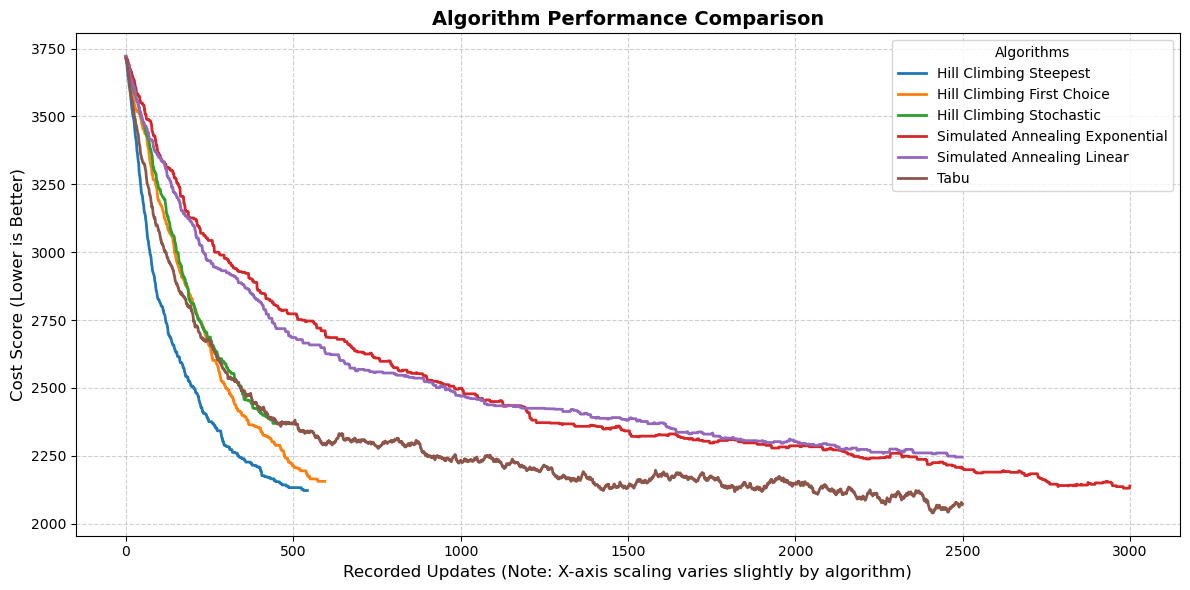

In [31]:
opt = Optimizer()
opt.compare_algorithms(prob, iterations=2500)

Loading problem …
  Events: 469  |  Rooms: 34
Plotting room occupancy heatmap …
  Saved → room_occupancy_heatmap.png
Plotting room utilization heatmap …
  Saved → room_utilization_heatmap.png
Plotting professor schedule heatmap …
  Saved → professor_schedule_heatmap.png
Done.


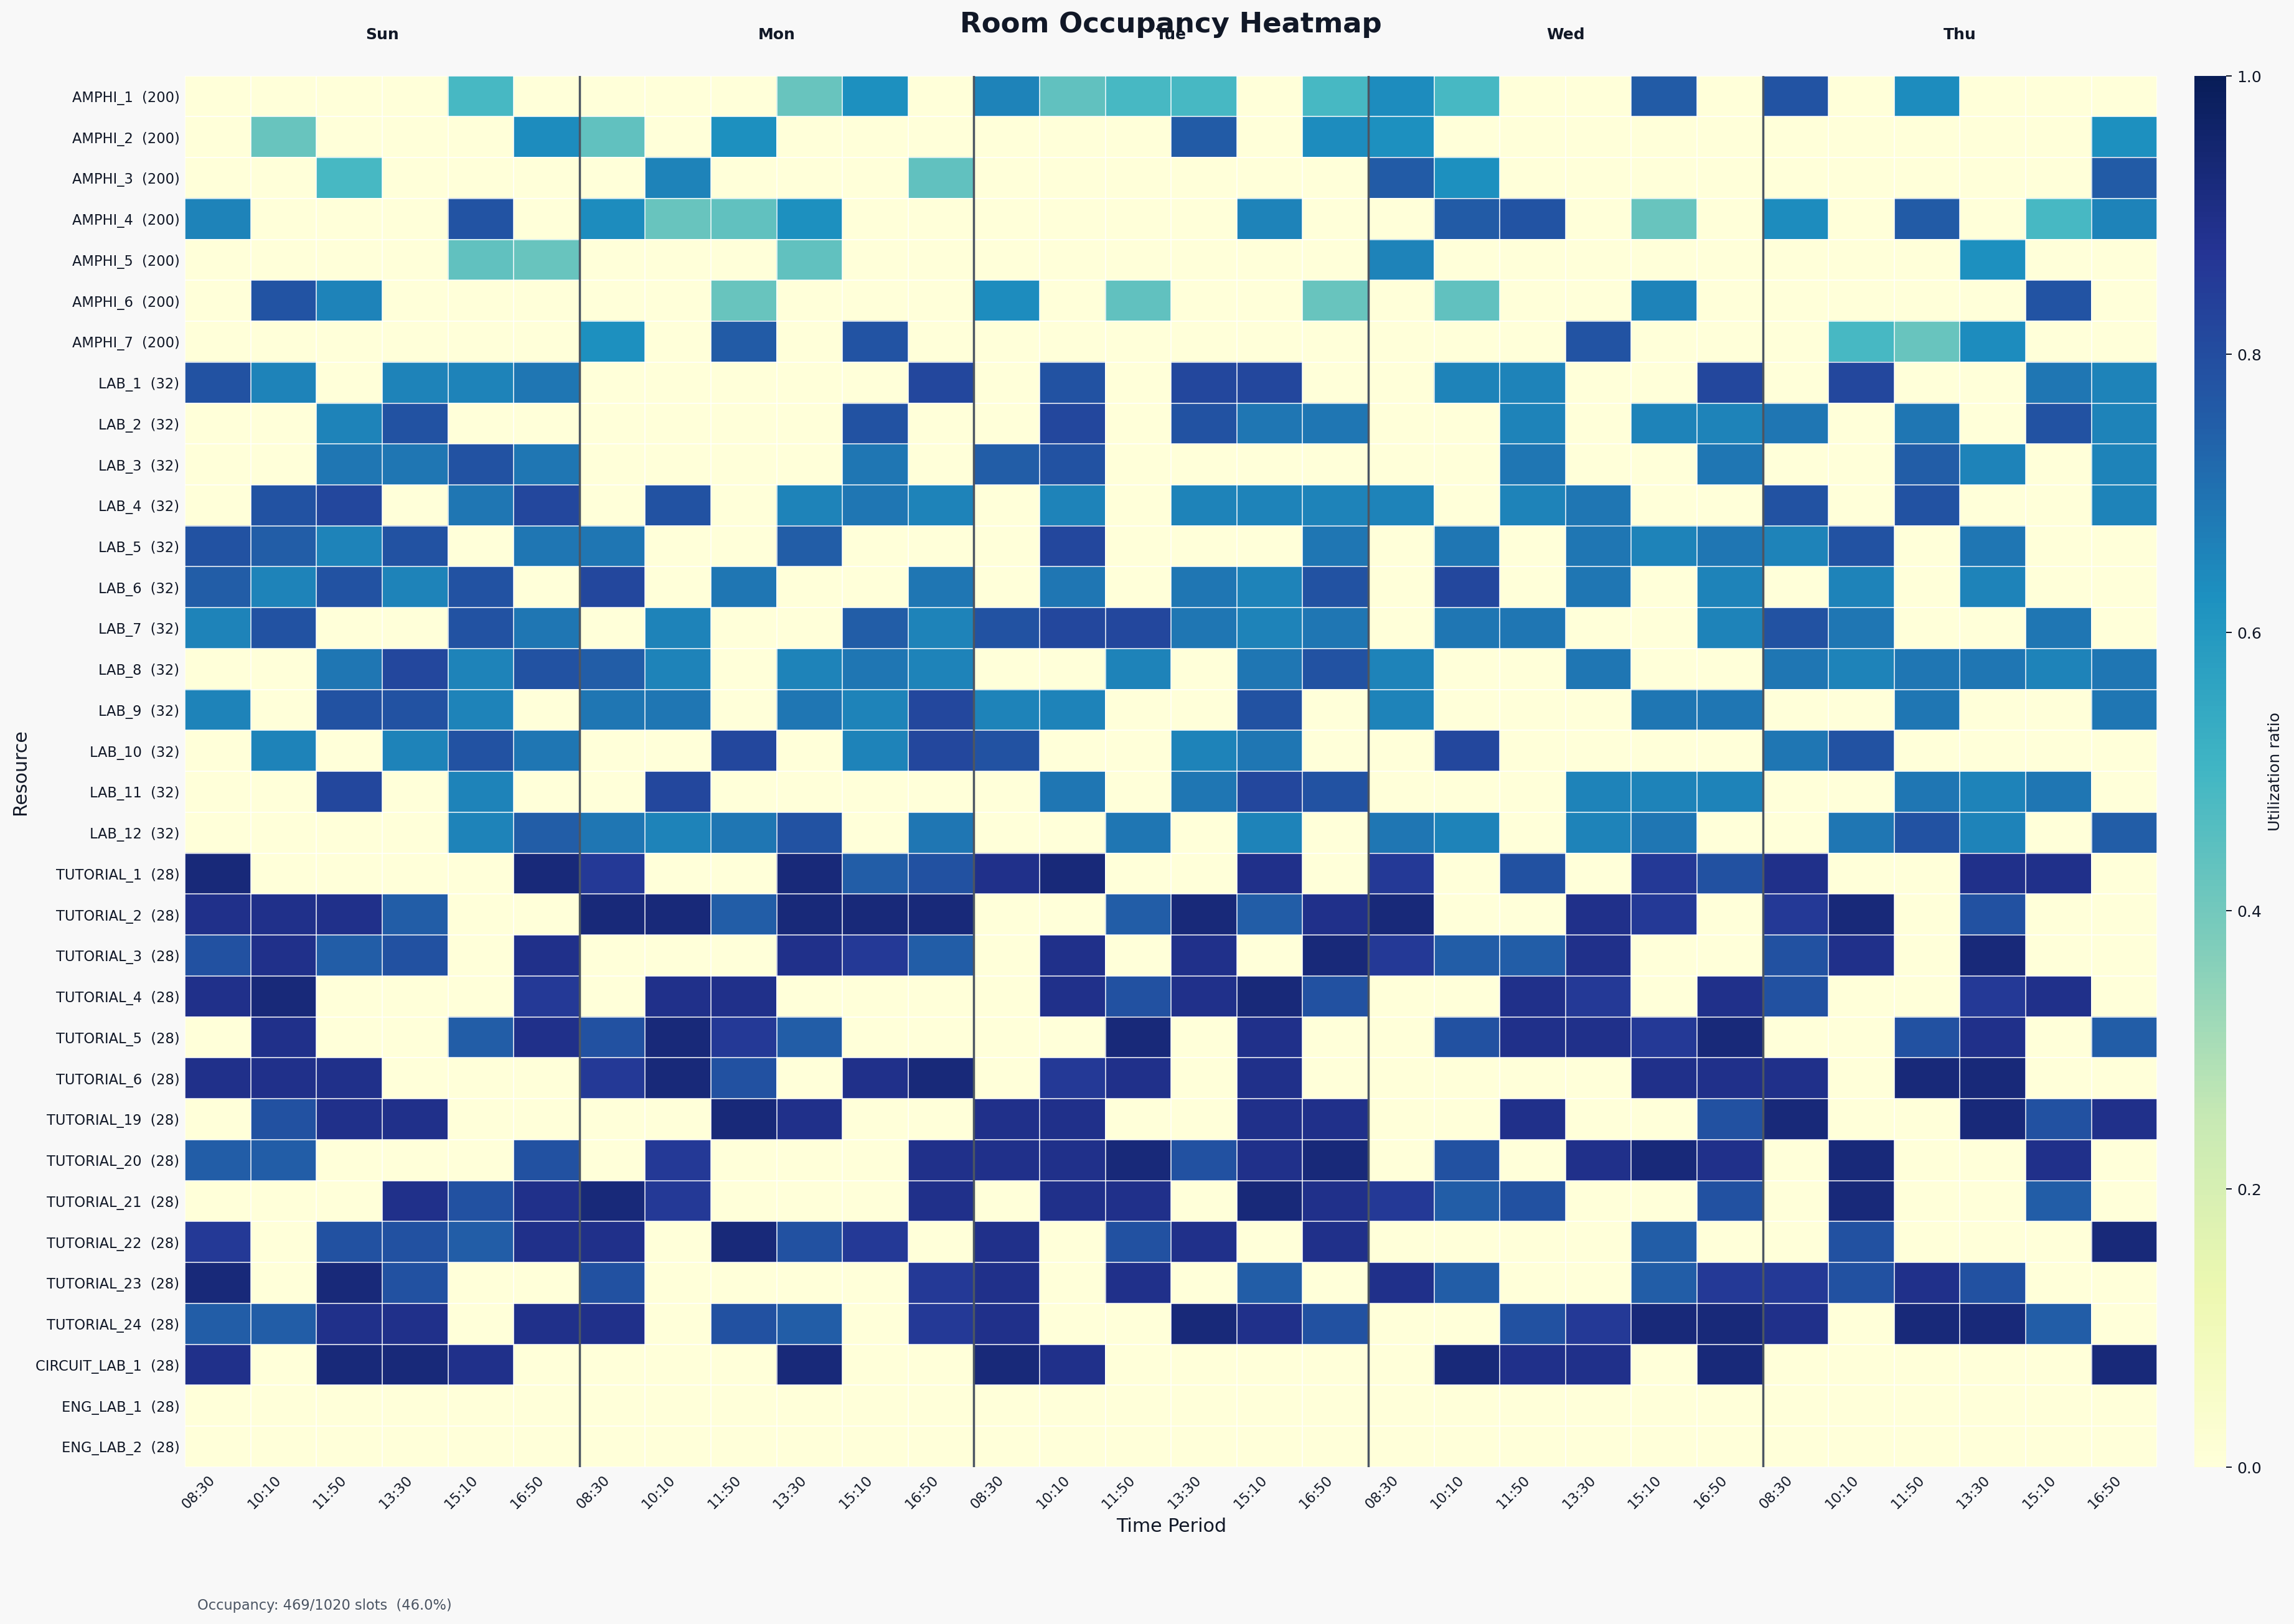

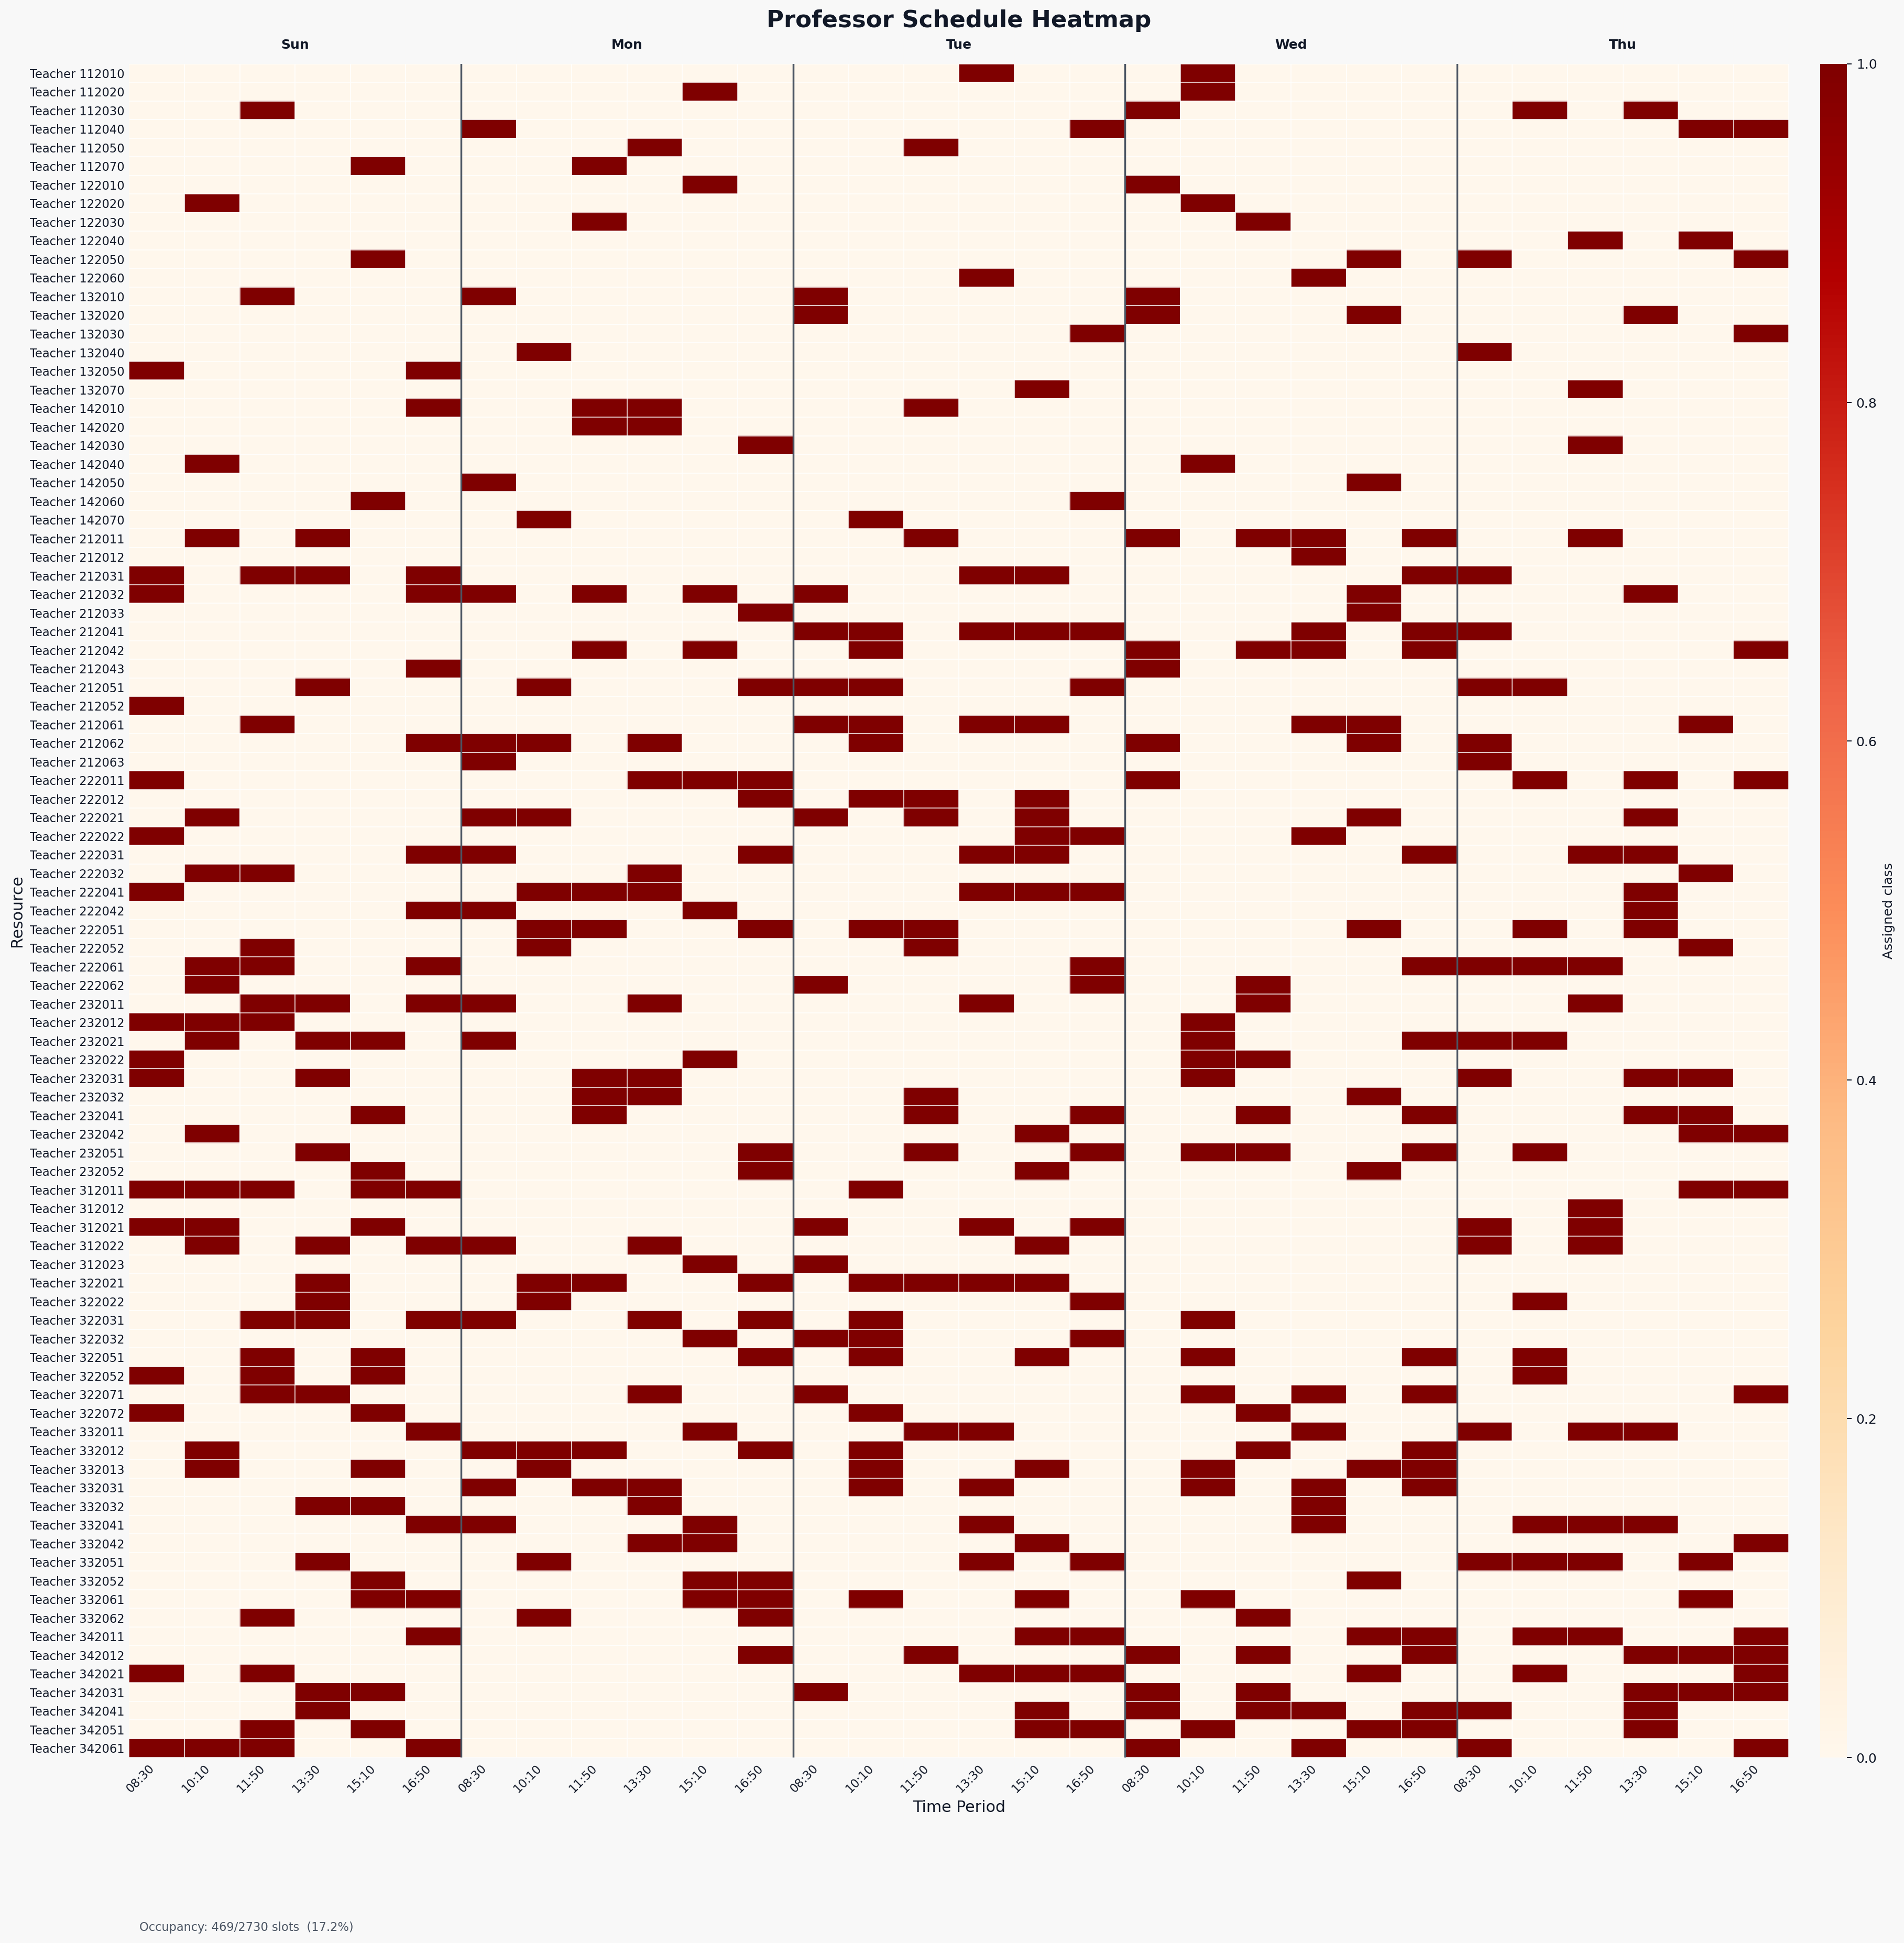

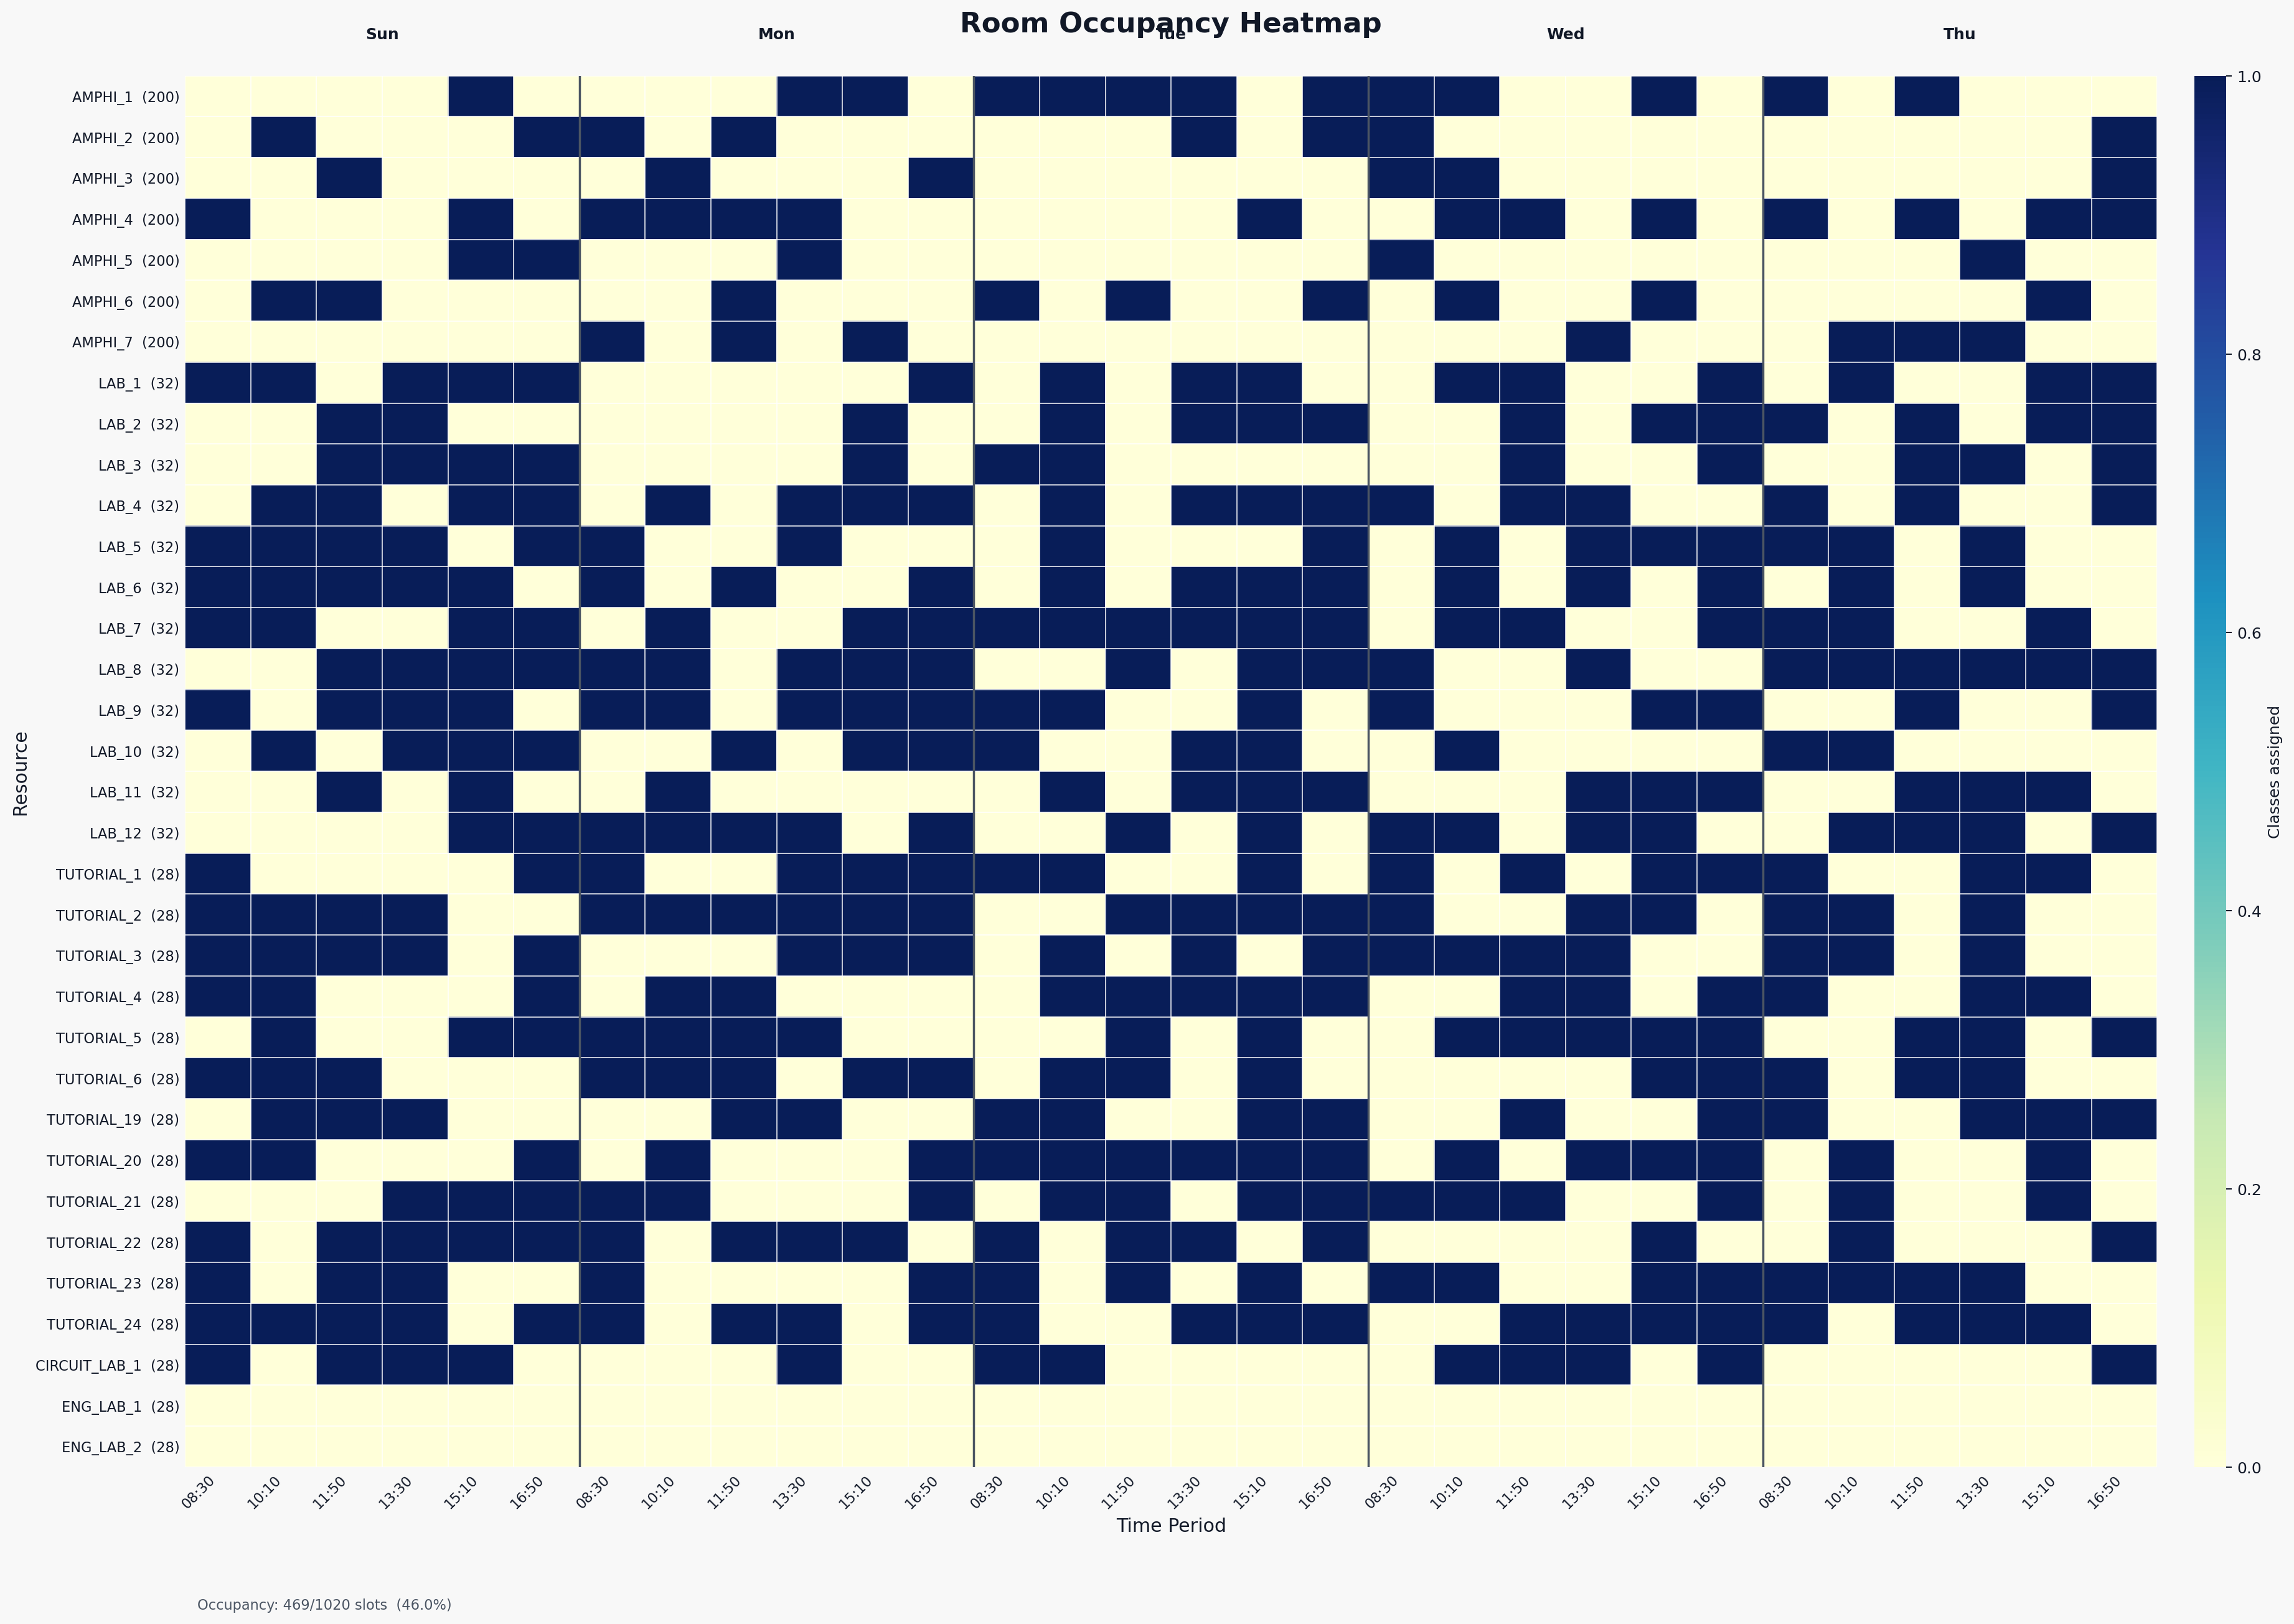

In [32]:
# get the pictures names then render them
res_names = run_vis()
for pic in res_names:
    display(Image(filename=pic))